# RQ3: To what extent personalities impact on HCS failures?

This notebook explains **why the failed-requests index spikes**, cell by cell over the
`event x personality` grid. 
It decomposes the level of the index during the event window into an *event*, a *personality* and an *interaction* term and finds the conditions under which each population fails. 

In [1]:
import itertools
import json
import pickle
import re
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

TRAPZ = getattr(np, "trapezoid", np.trapz)

In [2]:
%run utils.ipynb

## 1. Configuration and preprocessing

In [3]:
DATA_ROOT = Path("datasets/raw")
RQ1_DIR = Path("analysis_out/rq1-healthiness")   # Written by rq1-healthiness.ipynb
OUT_DIR = Path("analysis_out/rq3-analysis")
CACHE_DIR = Path("datasets/cache")
EVENT_START = 79200
EVENT_CATALOG = {
    "flash_mob": {"duration": 1800, "location": "midtown", "mechanism": "traffic slowdown (downtown 90%, midtown 70%)"},
    "underground_alarm": {"duration": 2700, "location": "downtown",  "mechanism": "demand surge +100% and traffic +100%"},
    "boycott_tncs": {"duration": 3600, "location": "all",  "mechanism": "demand collapse (requests -60%)"},
    "wildcat_strike": {"duration": 3600, "location": "all", "mechanism": "supply collapse (drivers -60%)"},
    "long_rides": {"duration": 7200, "location": "all", "mechanism": "ride lengths shifted to long/extreme"}
}
REFERENCE_SCENARIO = "normal"
KNOWN_SCENARIOS = ([REFERENCE_SCENARIO] + list(EVENT_CATALOG) + [f"{a}-{b}" for a, b in itertools.permutations(EVENT_CATALOG, 2)])
DRIVER_JOB_ALIASES = {"car, taxi and van drivers": "driver", "driver": "driver", "general": "general"}
PASSENGER_JOB_ALIASES = {"bank tellers": "bank_tellers", "bank_tellers": "bank_tellers",
                         "students": "students", "managers": "managers", "general": "general"}
PERSONALITY_ORDER = ["baseline", "bank_tellers", "students", "managers", "drivers",
                     "bank_tellers_drivers", "students_drivers", "managers_drivers"]
BASELINE = "baseline"
PASSENGER_ONLY = ["bank_tellers", "students", "managers"]
DRIVER_ONLY = "drivers"
COMBOS = {"bank_tellers_drivers": ("bank_tellers", DRIVER_ONLY),
          "students_drivers": ("students", DRIVER_ONLY),
          "managers_drivers": ("managers", DRIVER_ONLY)}
WINDOW_FILL = 60
AGGREGATE = 600
CUT = 7200
STRIDE = 20
ANALYSIS_START = 3600 + CUT - AGGREGATE 
DEMAND = "passengers_new"
FAILED_PARTS = ["rides_not_served", "passengers_cancel"]
FR_COMPONENTS = FAILED_PARTS + [DEMAND]
EXCLUDED_METRICS = {"rides_failed"}
THRESHOLD_BASELINE = "sf_normal_ocean"
THRESHOLD_BASELINE_RUN = (REFERENCE_SCENARIO, "general", "general")
HEALTHINESS_DIRS = [RQ1_DIR / "runs"]
FAILURE_RESULT_PATHS = [RQ1_DIR / "healthiness_results.csv"]
SPIKE_GAP_S = 600         # Exceedances closer than this belong to the same spike
MIN_SPIKE_S = 300         # Apikes shorter than this are noise
PRE_WINDOW_S = 3600       # Pre-spike reference window for the decomposition
LEAD_WINDOW_S = 900       # Window before spike onset, used to see what moves first
FLAT_RISE_EPS = 1e-3      # Below this the rise is too small to attribute to any driver
PLOT_STRIDE_S = 120       # Sampling of the index series exported for the dashboard plot
TOP_K = 5                 # Causes / traits reported per cell
Z_LARGE = 1.0             # |robust z| above which an effect is called large
CONSISTENCY_MIN = 1.0     # Fraction of cells that must agree in sign for a trait
PLOT_HEAD_CUT_S = 3 * 3600
PLOT_TAIL_CUT_S = 2 * 3600
USE_CACHE = True
OUT_DIR.mkdir(parents=True, exist_ok=True)
if USE_CACHE:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
METRIC_FAMILIES = {
    "demand": [
        "passengers_new", "passengers_departures", "passengers_arrivals",
        "passengers_unassigned", "passengers_drivers_ratio",
    ],
    "passenger_decisions": [
        "passengers_accept", "passengers_reject", "passengers_acceptance_rate",
        "passengers_cancel", "passengers_offers_discarded", "passengers_change_provider",
        "passengers_pickup_accept", "passengers_pickup_reject",
    ],
    "passenger_experience": [
        "passengers_rating_avg", "passengers_ratings_count", "passengers_no_ratings_count",
        "rides_waiting_duration_avg",
    ],
    "supply": [
        "drivers_idle", "drivers_pickup", "drivers_busy", "drivers_starting",
        "drivers_waiting", "drivers_removed", "drivers_shift_duration_avg",
        "drivers_idle_duration_avg", "drivers_occupied_distance_avg",
        "drivers_occupied_duration_avg", "drivers_total_length_avg",
        "drivers_passengers_served",
    ],
    "driver_decisions": [
        "drivers_accept", "drivers_reject", "drivers_acceptance_rate",
        "drivers_change_zone", "drivers_change_provider",
        "drivers_pickup_accept", "drivers_pickup_reject",
    ],
    "matching": [
        "rides_offers_generated", "rides_offers_lyft", "rides_offers_uber",
        "rides_offers_radius_avg", "rides_dispatched", "rides_partial_acceptances",
        "rides_in_progress", "rides_not_served",
    ],
    "market": [
        "drivers_demand_pressure", "rides_offers_price_no_surge_avg",
        "rides_offers_price_lyft_avg", "rides_offers_price_uber_avg",
        "rides_offers_surge_lyft_avg", "rides_offers_surge_uber_avg",
    ],
    "trip": [
        "rides_duration_avg", "rides_length_avg",
        "traffic_duration_avg", "traffic_length_avg", "traffic_speed_avg",
    ],
}
FAMILY_OF = {m: fam for fam, ms in METRIC_FAMILIES.items() for m in ms}

def family_of(metric: str) -> str:
    return FAMILY_OF.get(metric, "other")

def personality_of(driver_job: str, passenger_job: str) -> str:
    has_driver = driver_job == "driver"
    pas = "" if passenger_job == "general" else passenger_job
    if not pas:
        return DRIVER_ONLY if has_driver else BASELINE
    return f"{pas}_drivers" if has_driver else pas

def scenario_components(scen: str) -> list[str]:
    return [] if scen == REFERENCE_SCENARIO else scen.split("-")

def is_compound(scen: str) -> bool:
    return len(scenario_components(scen)) > 1

def event_window(scen: str) -> tuple[int, int]:
    comps = scenario_components(scen)
    if not comps:
        return EVENT_START, EVENT_START + min(e["duration"] for e in EVENT_CATALOG.values())
    durations = [EVENT_CATALOG[c]["duration"] for c in comps if c in EVENT_CATALOG]
    if not durations:
        raise KeyError(f"event '{scen}' has no component in EVENT_CATALOG")
    return EVENT_START, EVENT_START + max(durations)

def scenario_mechanism(scen: str) -> str:
    return " + ".join(EVENT_CATALOG[c]["mechanism"] for c in scenario_components(scen) if c in EVENT_CATALOG) or "none"

In [4]:
RUN_FILE_RE = re.compile(r"_dr_(?P<driver>.+?)_pass_(?P<passenger>.+)$")

def _scenario_from_filename(head: str) -> str | None:
    head = head[3:] if head.startswith("sf_") else head
    for cand in sorted(KNOWN_SCENARIOS, key=len, reverse=True):
        if head.startswith(cand.replace("-", "_")):
            return cand
    return None

def parse_run_path(path: Path) -> dict | None:
    m = RUN_FILE_RE.search(path.stem)
    if not m:
        return None
    driver_raw = m.group("driver").strip().lower()
    passenger_raw = m.group("passenger").strip().lower()
    driver_job = DRIVER_JOB_ALIASES.get(driver_raw)
    passenger_job = PASSENGER_JOB_ALIASES.get(passenger_raw)
    if driver_job is None or passenger_job is None:
        return None
    parts = path.parts
    scenario = None
    if len(parts) >= 3 and parts[-2] == "ocean" and parts[-3] in KNOWN_SCENARIOS:
        scenario = parts[-3]
    if (scenario is None and len(parts) >= 4 and parts[-3] == "ocean"
            and parts[-4] in KNOWN_SCENARIOS):
        scenario = parts[-4]
    if scenario is None:
        scenario = _scenario_from_filename(path.stem[:m.start()])
    if scenario is None and path.parent.name in KNOWN_SCENARIOS:
        scenario = path.parent.name
    if scenario is None:
        return None
    return {"scenario": scenario, "driver_job": driver_job, "passenger_job": passenger_job,
            "personality": personality_of(driver_job, passenger_job), "path": path}

candidate_files = sorted(p for p in DATA_ROOT.rglob("*.csv") if "_dr_" in p.name)
parsed, unparsed = [], []
for p in candidate_files:
    info = parse_run_path(p)
    (parsed if info else unparsed).append(info or p)
catalog = pd.DataFrame(parsed)
if catalog.empty:
    raise FileNotFoundError(
        f"No run CSV found under {DATA_ROOT.resolve()}. Expected files named '..._dr_<driver job>_pass_<passenger job>.csv'."
    )
catalog["is_compound"] = catalog["scenario"].map(is_compound)
catalog["components"] = catalog["scenario"].map(lambda s: "+".join(scenario_components(s)))
catalog["mechanism"] = catalog["scenario"].map(scenario_mechanism)
SCENARIOS = sorted(catalog.scenario.unique(), key=lambda s: (s != REFERENCE_SCENARIO, is_compound(s), s))
PERSONALITIES = [p for p in PERSONALITY_ORDER if p in set(catalog.personality)]
EVENT_SCENARIOS = [s for s in SCENARIOS if s != REFERENCE_SCENARIO]
SINGLE_SCENARIOS = [s for s in EVENT_SCENARIOS if not is_compound(s)]
COMPOUND_SCENARIOS = [s for s in EVENT_SCENARIOS if is_compound(s)]
print(f"{len(catalog)} runs: {len(SCENARIOS)} events "
      f"({len(SINGLE_SCENARIOS)} single, {len(COMPOUND_SCENARIOS)} compound) x {len(PERSONALITIES)} personalities")
if unparsed:
    print(f"\n{len(unparsed)} file(s) could not be identified and were skipped:")
    for p in unparsed[:10]:
        print(f"  {p}")

120 runs: 15 events (5 single, 9 compound) x 8 personalities


In [5]:
def load_run(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = pd.read_csv(path)
    df = fill_missing_data(df, WINDOW_FILL)
    ts = df["timestamp"].to_numpy()
    cols = [c for c in df.columns if c != "timestamp"]
    smoothed = df[cols].rolling(window=AGGREGATE).mean().round(5)
    smoothed.insert(0, "timestamp", ts)
    if len(smoothed) <= ANALYSIS_START + CUT:
        raise ValueError(f"{path.name}: {len(smoothed)} rows, needs more than "
                         f"{ANALYSIS_START + CUT} for the warm-up/tail cut")
    smoothed = smoothed.iloc[ANALYSIS_START:len(smoothed) - CUT]
    full = smoothed[["timestamp"] + FR_COMPONENTS].reset_index(drop=True)
    return smoothed.iloc[::STRIDE].reset_index(drop=True), full

def load_run_cached(row) -> tuple[pd.DataFrame, pd.DataFrame]:
    path = Path(row["path"])
    if not USE_CACHE:
        return load_run(path)
    key = f"{row['scenario']}__{row['personality']}__s{STRIDE}_v2.pkl"
    cache = CACHE_DIR / key
    if cache.exists() and cache.stat().st_mtime >= path.stat().st_mtime:
        return pd.read_pickle(cache)
    out = load_run(path)
    pd.to_pickle(out, cache)
    return out

In [6]:
def compute_threshold_baseline(path: Path) -> dict:
    """The thresholds of utils.ipynb's compute_thresholds, fitted on one run, as a dict."""
    p99_h, p99_c, p99_r, a, b, c = compute_thresholds(pd.read_csv(path), AGGREGATE, CUT)
    return {"a": float(a), "b": float(b), "c": float(c),
            "p99_h": float(p99_h), "p99_c": float(p99_c), "p99_r": int(p99_r)}


base_row = catalog[(catalog.scenario == THRESHOLD_BASELINE_RUN[0])
                   & (catalog.driver_job == THRESHOLD_BASELINE_RUN[1])
                   & (catalog.passenger_job == THRESHOLD_BASELINE_RUN[2])]
if base_row.empty:
    raise FileNotFoundError(f"threshold-baseline run {THRESHOLD_BASELINE_RUN} not found under {DATA_ROOT}")
thresholds = compute_threshold_baseline(Path(base_row.iloc[0]["path"]))
FR_PARAMS = (thresholds["a"], thresholds["b"], thresholds["c"])
FR_THRESHOLD = float(thresholds["p99_h"])

In [7]:
PKL_RE = re.compile(r"^thresholds_(?P<rest>.+)$")

def parse_threshold_pkl(stem: str, baseline: str) -> tuple[str, str, str] | None:
    m = PKL_RE.match(stem)
    if not m:
        return None
    rest = m.group("rest")
    if not rest.endswith(f"_{baseline}"):
        return None
    rest = rest[: -(len(baseline) + 1)]
    for scen in sorted(KNOWN_SCENARIOS, key=len, reverse=True):
        if rest.startswith(scen + "_"):
            tail = rest[len(scen) + 1:]
            for driver_raw in sorted(DRIVER_JOB_ALIASES, key=len, reverse=True):
                if tail.startswith(driver_raw + "_"):
                    passenger_raw = tail[len(driver_raw) + 1:]
                    driver = DRIVER_JOB_ALIASES[driver_raw]
                    passenger = PASSENGER_JOB_ALIASES.get(passenger_raw)
                    if passenger is None:
                        return None
                    return scen, driver, passenger
    return None

healthiness_raw: dict[tuple[str, str], tuple] = {}

def load_healthiness_output() -> tuple[dict, dict]:
    series, verdicts = {}, {}
    source_dir = next((d for d in HEALTHINESS_DIRS if d.exists()), None)
    if source_dir is None:
        return series, verdicts
    for pkl in sorted(source_dir.glob("thresholds_*.pkl")):
        parsed = parse_threshold_pkl(pkl.stem, THRESHOLD_BASELINE)
        if parsed is None:
            continue
        scenario, driver, passenger = parsed
        key = (personality_of(driver, passenger), scenario)
        try:
            with open(pkl, "rb") as f:
                payload = pickle.load(f)
        except Exception as exc:
            print(f"  could not read {pkl.name}: {exc}")
            continue
        hardiness, failure_timestamp = payload[0], payload[-1]
        healthiness_raw[key] = payload
        values = np.asarray(hardiness, dtype=float)
        series[key] = pd.DataFrame({
            "timestamp": np.arange(ANALYSIS_START, ANALYSIS_START + len(values)),
            "failed_requests": values
        })
        verdicts[key] = {
            "failure": bool(failure_timestamp > 0),
            "failure_timestamp": (int(failure_timestamp) + ANALYSIS_START if failure_timestamp > 0 else None)
        }
    if series:
        print(f"Index consumed from {source_dir} for {len(series)} cells")
    return series, verdicts

healthiness_series, healthiness_verdicts = load_healthiness_output()
failure_table = None
for candidate in FAILURE_RESULT_PATHS:
    if candidate.exists():
        failure_table = pd.read_csv(candidate)
        print(f"Failure verdicts read from {candidate}")
        break
if failure_table is not None and {"driver_job", "passenger_job"}.issubset(failure_table.columns):
    failure_table = failure_table.copy()
    failure_table["personality"] = [
        personality_of(DRIVER_JOB_ALIASES.get(str(d).strip().lower(), ""),
                       PASSENGER_JOB_ALIASES.get(str(p).strip().lower(), ""))
        for d, p in zip(failure_table.driver_job, failure_table.passenger_job)]
    if "baseline" in failure_table.columns:
        failure_table = failure_table[failure_table.baseline == THRESHOLD_BASELINE]

Index consumed from analysis_out/rq1-healthiness/runs for 120 cells
Failure verdicts read from analysis_out/rq1-healthiness/healthiness_results.csv


In [8]:
runs: dict[tuple[str, str], pd.DataFrame] = {}
index_full: dict[tuple[str, str], np.ndarray] = {}
index_source: dict[tuple[str, str], str] = {}

for _, row in catalog.iterrows():
    key = (row["personality"], row["scenario"])
    df, full = load_run_cached(row)
    exported = healthiness_series.get(key)
    if exported is not None and len(exported) >= len(full) - STRIDE:
        series_1hz = exported
        index_source[key] = "rq1-healthiness"
    else:
        series_1hz = pd.DataFrame({
            "timestamp": full["timestamp"].to_numpy(),
            "failed_requests": [compute_failed_requests(*FR_PARAMS, failed=ns + ca, requested=d)
                                for ns, ca, d in zip(full[FAILED_PARTS[0]], full[FAILED_PARTS[1]], full[DEMAND])]})
        index_source[key] = "recomputed"
    index_full[key] = series_1hz["failed_requests"].to_numpy(dtype=float)
    runs[key] = df.merge(series_1hz, on="timestamp", how="left")

sources = pd.Series(index_source).value_counts()
print(f"Loaded {len(runs)} runs; index source: {sources.to_dict()}")
NON_FEATURES = {"timestamp", "failed_requests"}
metric_cols = sorted(set.intersection(*[set(d.columns) for d in runs.values()]) - NON_FEATURES - EXCLUDED_METRICS)
for needed in FR_COMPONENTS:
    assert needed in metric_cols, f"{needed} is required by the index but is missing"
REF_KEY = (BASELINE, REFERENCE_SCENARIO)
if REF_KEY not in runs:
    raise FileNotFoundError(
        f"Reference run {REF_KEY} (dr_general_pass_general under '{REFERENCE_SCENARIO}') is "
        "missing. Every metric contrast below is expressed relative to it."
    )

unassigned = [m for m in metric_cols if m not in FAMILY_OF]
if unassigned:
    print(f"Metrics without a family (reported as 'other'): {unassigned}")

Loaded 120 runs; index source: {'rq1-healthiness': 120}


## 2. The failed requests index over time

In [9]:
def window_mask(ts, start, end):
    ts = np.asarray(ts, dtype=float)
    return (ts >= start) & (ts < end)

fr_overview = []
for (pers, scen), df in runs.items():
    s, e = event_window(scen)
    x = df["failed_requests"].to_numpy()
    m_ev = window_mask(df["timestamp"], s, e)
    fr_overview.append({
        "scenario": scen, "personality": pers,
        "is_compound": is_compound(scen), "mechanism": scenario_mechanism(scen),
        "fr_mean": float(np.nanmean(x)),
        "fr_p99": float(np.nanpercentile(x, 99)),
        "fr_peak": float(np.nanmax(x)),
        "fr_mean_event": float(np.nanmean(x[m_ev])) if m_ev.any() else np.nan,
        "minutes_above_threshold": float((x > FR_THRESHOLD).sum() * STRIDE / 60.0),
        "index_source": index_source.get((pers, scen), "unknown"),
    })
fr_overview = pd.DataFrame(fr_overview)
fr_overview.to_csv(OUT_DIR / "failed_requests_overview.csv", index=False)

# The index series itself, decimated for plotting
plot_step = max(1, PLOT_STRIDE_S // STRIDE)
SIM_END = int(max(df["timestamp"].iloc[-1] for df in runs.values())) + CUT
PLOT_WINDOW = (PLOT_HEAD_CUT_S, SIM_END - PLOT_TAIL_CUT_S)
index_series = pd.concat(
    [pd.DataFrame({"scenario": scen, "personality": pers,
                   "timestamp": df["timestamp"].to_numpy()[::plot_step],
                   "failed_requests": df["failed_requests"].to_numpy()[::plot_step].round(4)})
     for (pers, scen), df in runs.items()],
    ignore_index=True)
index_series = index_series[index_series.timestamp.between(*PLOT_WINDOW)].reset_index(drop=True)
index_series.to_csv(OUT_DIR / "index_series.csv", index=False)
print("Mean index during the event window:")
display(fr_overview.pivot(index="personality", columns="scenario", values="fr_mean_event").reindex(index=PERSONALITIES, columns=SCENARIOS).round(4).rename_axis(columns="event"))

Mean index during the event window:


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,0.1769,0.1152,0.2163,0.1827,0.1774,0.1704,0.1107,0.2228,0.2446,0.2552,0.2252,0.3558,0.2023,0.1378,0.2185
bank_tellers,0.1676,0.1326,0.2394,0.2118,0.2082,0.2127,0.1372,0.2370,0.2800,0.2639,0.2532,0.3485,0.2478,0.1196,0.2367
students,0.1745,0.1386,0.2215,0.1946,0.1789,0.1744,0.1252,0.2256,0.2497,0.2452,0.2461,0.3425,0.2206,0.1440,0.2215
managers,0.1814,0.1298,0.2285,0.2087,0.1952,0.1947,0.1289,0.2612,0.2628,0.2477,0.2393,0.3572,0.2466,0.1505,0.2424
drivers,0.1639,0.1372,0.2375,0.2176,0.1769,0.1692,0.1192,0.2412,0.2666,0.2468,0.2221,0.3745,0.2238,0.1360,0.2241
bank_tellers_drivers,0.1834,0.1259,0.2537,0.2355,0.2092,0.2011,0.1361,0.2533,0.2813,0.2719,0.2651,0.3958,0.2530,0.1806,0.2564
students_drivers,0.1637,0.1226,0.2252,0.2191,0.1917,0.1733,0.1274,0.2182,0.2767,0.2527,0.2323,0.3614,0.2228,0.1369,0.2241
managers_drivers,0.1821,0.1551,0.2310,0.2221,0.2009,0.1788,0.1372,0.2624,0.2931,0.2469,0.2460,0.3711,0.2444,0.1394,0.2501


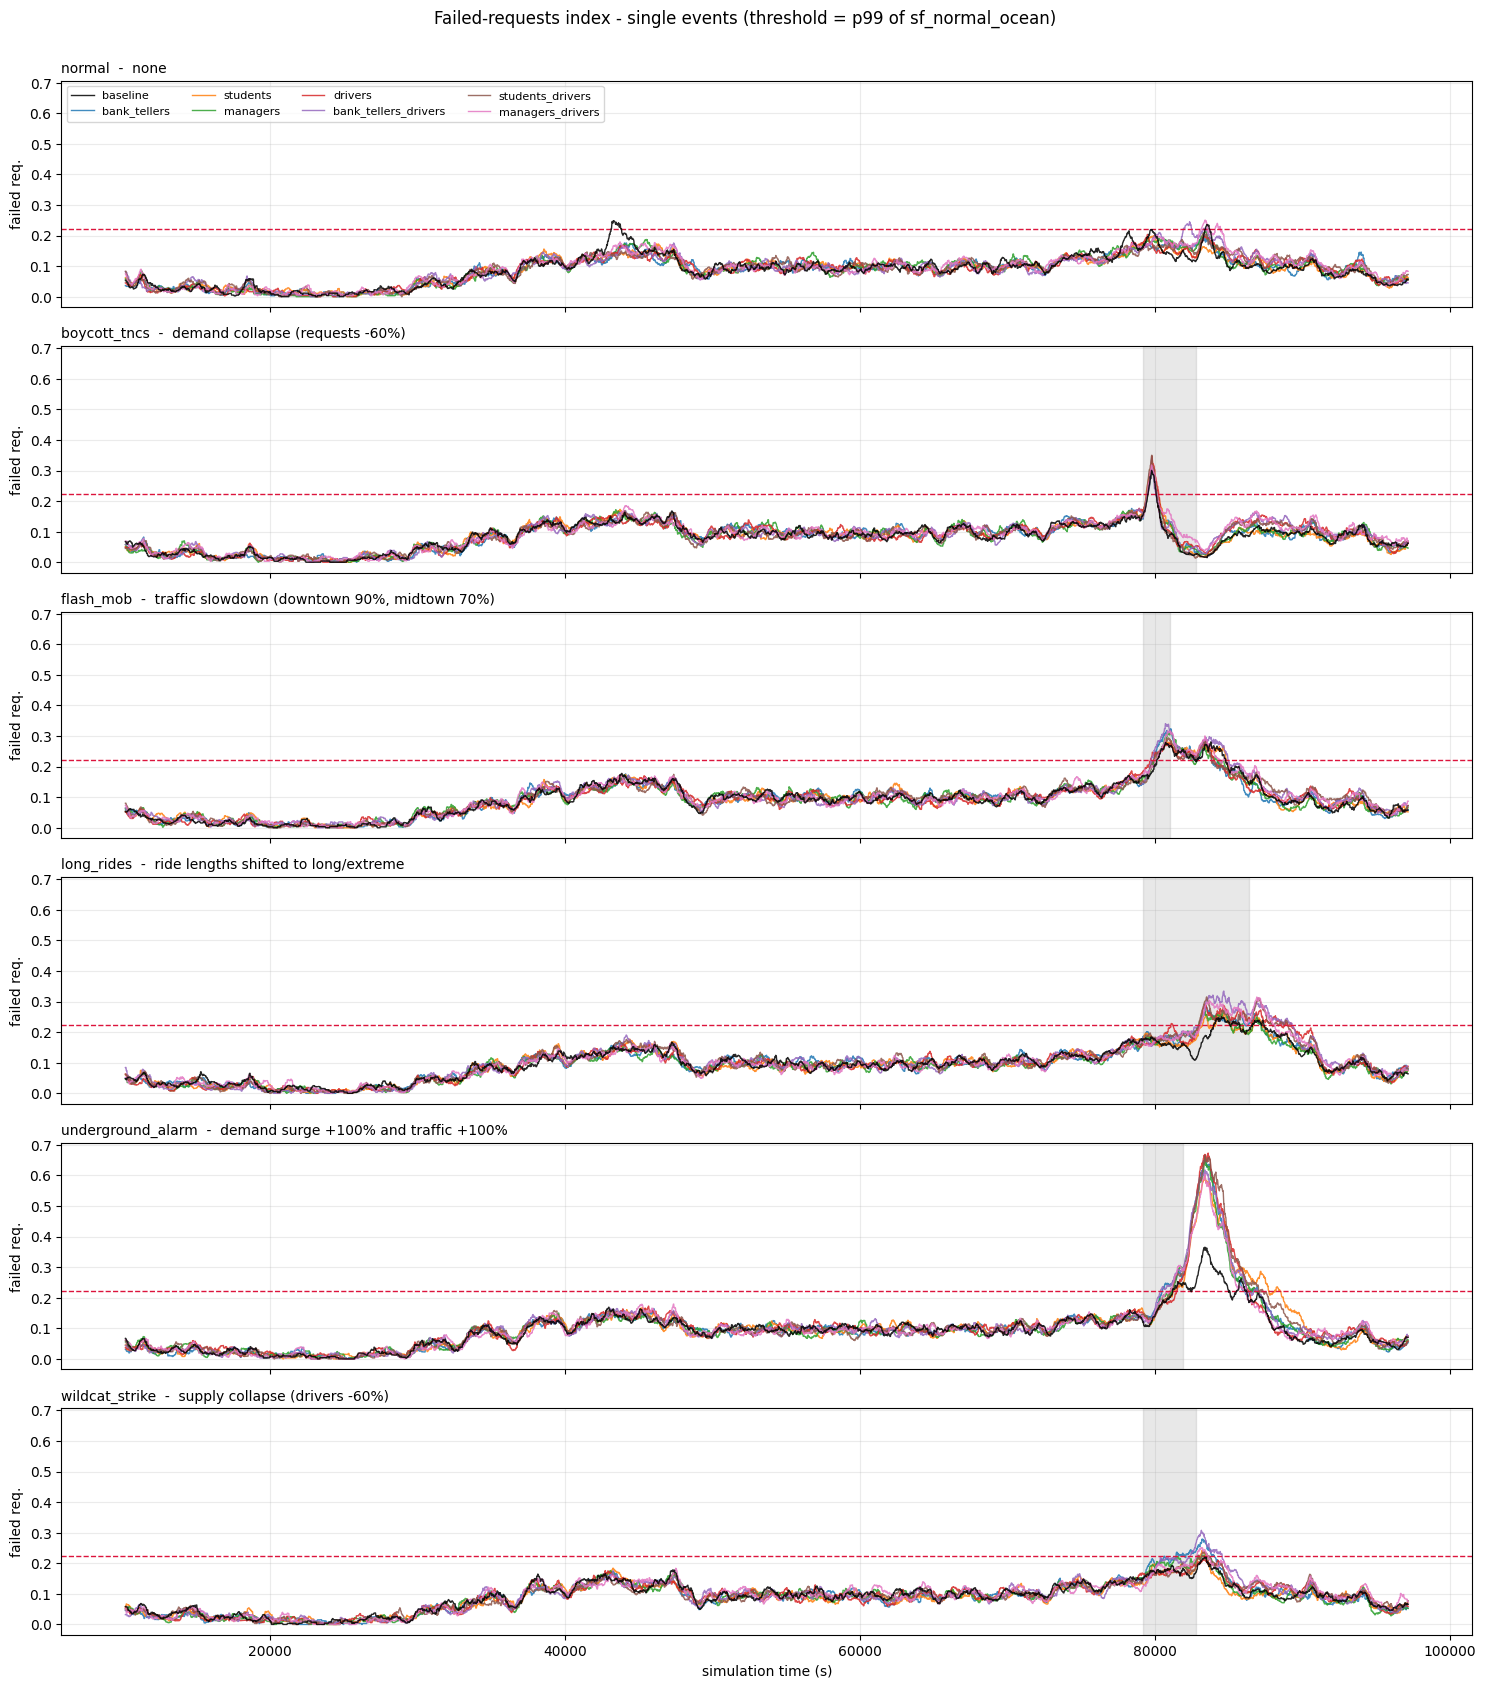

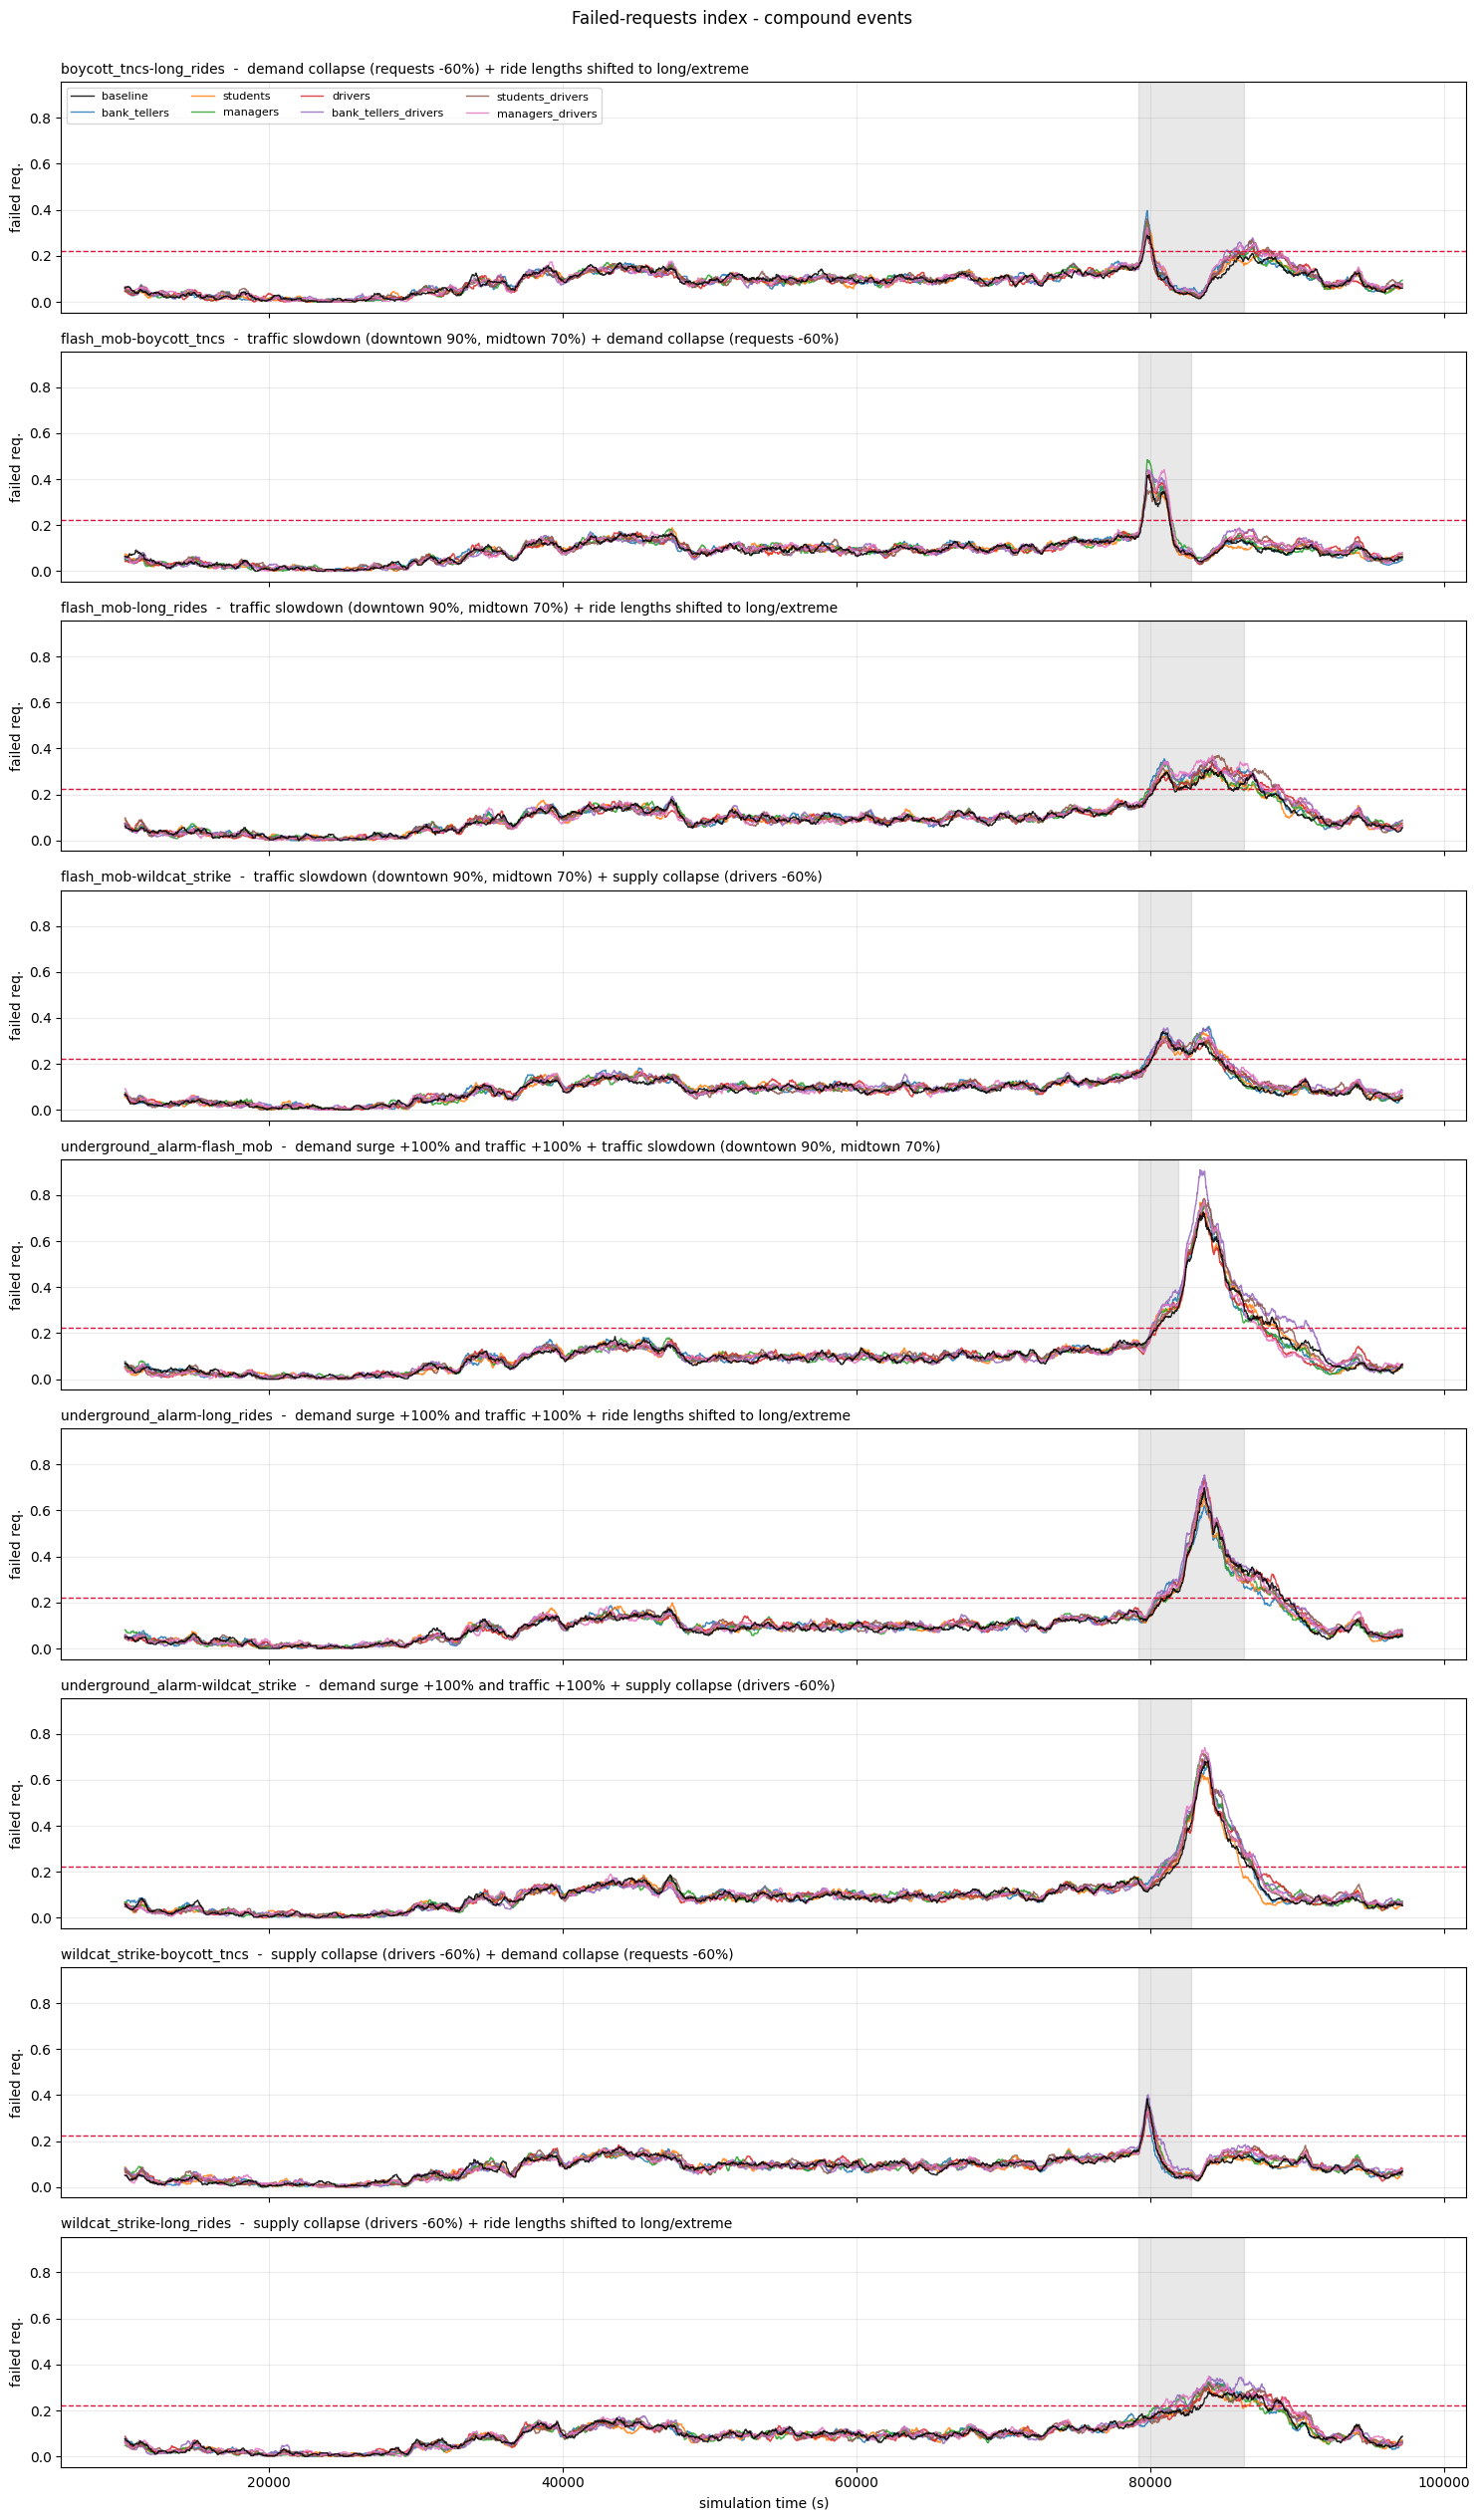

In [10]:
def plot_index(scenarios: list[str], title: str, filename: str, save: bool = True):
    scens = [s for s in scenarios if any((p, s) in runs for p in PERSONALITIES)]
    if not scens:
        return
    fig, axes = plt.subplots(len(scens), 1, figsize=(15, 2.8 * len(scens)), sharex=True, sharey=True, squeeze=False)
    for ax, scen in zip(axes[:, 0], scens):
        for pers in PERSONALITIES:
            df = runs.get((pers, scen))
            if df is None:
                continue
            ax.plot(df["timestamp"], df["failed_requests"], linewidth=1.0, alpha=0.85,
                    label=pers, color="black" if pers == BASELINE else None,
                    zorder=3 if pers == BASELINE else 2)
        s, e = event_window(scen)
        if scen != REFERENCE_SCENARIO:
            ax.axvspan(s, e, color="grey", alpha=0.18, zorder=1)
        ax.axhline(FR_THRESHOLD, color="crimson", linestyle="--", linewidth=1.0)
        ax.set_title(f"{scen}  -  {scenario_mechanism(scen)}", fontsize=10, loc="left")
        ax.grid(alpha=0.25)
        ax.set_ylabel("failed req.")
    axes[0, 0].legend(loc="upper left", fontsize=8, ncol=4)
    axes[-1, 0].set_xlabel("simulation time (s)")
    fig.suptitle(title, y=1.002)
    plt.tight_layout()
    if save:
        plt.savefig(OUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_index([REFERENCE_SCENARIO] + SINGLE_SCENARIOS,
           f"Failed-requests index - single events (threshold = p99 of {THRESHOLD_BASELINE})",
           "failed_requests_single.png")
plot_index(COMPOUND_SCENARIOS,
           "Failed-requests index - compound events", "failed_requests_compound.png")

## 3. Spike detection

A spike is a stretch where the index exceeds the threshold.
Each episode gets a severity (`area`, the integral of the excess over the threshold), a peak, its position relative to the injected window (`during`, `post` within the following hour, or `outside`), and whether it contains the HCS failure timestamp that `rq1-healthiness.ipynb` reported for the same cell.

In [11]:
def find_spikes(ts, x, threshold: float,
                gap_s: int = SPIKE_GAP_S, min_duration_s: int = MIN_SPIKE_S) -> list[dict]:
    ts = np.asarray(ts, dtype=float)
    x = np.asarray(x, dtype=float)
    idx = np.flatnonzero(np.isfinite(x) & (x > threshold))
    if idx.size == 0:
        return []
    breaks = np.flatnonzero(np.diff(ts[idx]) > gap_s)
    starts = idx[np.insert(breaks + 1, 0, 0)]
    ends = idx[np.append(breaks, len(idx) - 1)]

    episodes = []
    for s, e in zip(starts, ends):
        duration = ts[e] - ts[s] + STRIDE
        if duration < min_duration_s:
            continue
        seg_t, seg_x = ts[s:e + 1], x[s:e + 1]
        episodes.append({
            "start_ts": float(ts[s]), "end_ts": float(ts[e] + STRIDE),
            "duration_s": float(duration),
            "peak": float(seg_x.max()), "peak_ts": float(seg_t[int(seg_x.argmax())]),
            "mean": float(seg_x.mean()),
            "area": float(TRAPZ(np.clip(seg_x - threshold, 0, None), seg_t)) if len(seg_t) > 1 else 0.0,
        })
    return episodes


def classify_spike(scen: str, start_ts: float, end_ts: float) -> str:
    if scen == REFERENCE_SCENARIO:
        return "outside"
    s, e = event_window(scen)
    if start_ts < e and end_ts > s:
        return "during"
    if e <= start_ts < e + 3600:
        return "post"
    return "outside"


spike_rows = []
for (pers, scen), df in runs.items():
    verdict = healthiness_verdicts.get((pers, scen), {})
    fail_ts = verdict.get("failure_timestamp")
    for k, ep in enumerate(find_spikes(df["timestamp"], df["failed_requests"], FR_THRESHOLD)):
        spike_rows.append({
            "scenario": scen, "personality": pers, "spike_id": f"{scen}|{pers}|{k}", **ep,
            "duration_min": ep["duration_s"] / 60.0,
            "position": classify_spike(scen, ep["start_ts"], ep["end_ts"]),
            "contains_failure": bool(fail_ts is not None
                                     and ep["start_ts"] <= fail_ts < ep["end_ts"]),
        })
spikes = pd.DataFrame(spike_rows)
spikes.to_csv(OUT_DIR / "spikes.csv", index=False)

if spikes.empty:
    print("No spike exceeds the threshold in any run.")
else:
    print(f"{len(spikes)} spikes across {spikes.groupby(['scenario', 'personality']).ngroups} cells; "
          f"{int(spikes.contains_failure.sum())} contain the reported SHE failure")
    print("\nMinutes in spike per cell:")
    display(spikes.pivot_table(index="personality", columns="scenario", values="duration_min",
                               aggfunc="sum").reindex(index=PERSONALITIES, columns=SCENARIOS)
            .fillna(0.0).round(1).rename_axis(columns="event"))

122 spikes across 113 cells; 56 contain the reported SHE failure

Minutes in spike per cell:


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,10.3,9.3,77.7,43.3,83.7,0.0,10.0,31.0,119.3,75.3,136.7,131.7,88.7,13.7,92.7
bank_tellers,0.0,11.0,65.0,70.3,108.0,43.3,31.0,32.3,128.0,84.0,126.7,116.3,100.0,11.0,86.0
students,0.0,13.3,81.0,43.3,120.0,8.0,12.0,32.3,119.0,87.0,144.0,121.3,78.0,15.0,84.7
managers,0.0,11.3,69.0,45.7,93.3,8.0,11.0,33.7,123.3,70.3,123.3,133.0,104.3,15.0,100.0
drivers,0.0,12.7,71.3,103.7,81.0,0.0,34.7,32.0,145.3,74.7,121.0,133.0,96.7,12.3,110.0
bank_tellers_drivers,9.3,9.7,86.7,105.3,110.3,36.0,45.7,32.0,141.0,86.3,180.0,140.0,113.0,19.3,127.3
students_drivers,0.0,11.7,65.0,101.3,104.3,12.0,38.3,31.0,148.3,82.3,142.7,131.7,96.3,14.3,104.7
managers_drivers,21.7,11.0,80.0,84.3,84.3,13.7,41.3,33.7,149.3,79.3,121.3,137.0,103.0,14.7,133.0


In [12]:
# A failing spike can be read against all three thresholds
detail_rows = []
for (pers, scen), payload in healthiness_raw.items():
    (hardiness, exceed_h, exceed_c, exceed_r, p99_h, p99_c, p99_r,
     consecutive_t, failure_ts) = payload
    if not failure_ts:
        continue
    idx = pd.Series(np.asarray(hardiness, dtype=float))
    consistency = idx.rolling(window=AGGREGATE).std().fillna(0).to_numpy()
    ts = np.arange(ANALYSIS_START, ANALYSIS_START + len(idx))
    full_h = np.flatnonzero(idx.to_numpy() > p99_h)
    full_c = np.flatnonzero(consistency > p99_c)
    run_ticks, rebuilt_ts = np.nan, None
    for er, run_len in zip(exceed_r, consecutive_t):
        w0, w1 = er - p99_r, er - p99_r + run_len
        hi = full_h[(full_h >= w0) & (full_h <= w1)]
        ci = full_c[(full_c >= w0) & (full_c <= w1)]
        if hi.size and ci.size:
            run_ticks = float(run_len)
            rebuilt_ts = int(max(hi[0], ci[0], er))
            break
    sp = spikes[(spikes.scenario == scen) & (spikes.personality == pers) & spikes.contains_failure]
    if sp.empty:
        continue
    inside = (ts >= float(sp.iloc[0]["start_ts"])) & (ts < float(sp.iloc[0]["end_ts"]))
    if not inside.any():
        continue
    detail_rows.append({
        "scenario": scen, "personality": pers,
        "hardiness_peak": float(idx.to_numpy()[inside].max()),
        "consistency_peak": float(consistency[inside].max()),
        "resilience_ticks": run_ticks,
        "rebuilt_matches": bool(rebuilt_ts == int(failure_ts)),
        "p99_h": float(p99_h), "p99_c": float(p99_c), "p99_r": float(p99_r),
    })
failure_detail = pd.DataFrame(detail_rows, columns=[
    "scenario", "personality", "hardiness_peak", "consistency_peak", "resilience_ticks",
    "rebuilt_matches", "p99_h", "p99_c", "p99_r"])
failure_detail.to_csv(OUT_DIR / "failure_detail.csv", index=False)

## 4. Spike decomposition

In [13]:
def _fr_scalar(ns: float, ca: float, d: float, a: float, b: float, c: float) -> float:
    return float(compute_failed_requests(a, b, c, failed=ns + ca, requested=d))

def shapley_decomposition(pre, post, params) -> dict[str, float]:
    contrib = np.zeros(3)
    for perm in itertools.permutations(range(3)):
        cur = list(pre)
        prev = _fr_scalar(*cur, *params)
        for k in perm:
            cur[k] = post[k]
            nxt = _fr_scalar(*cur, *params)
            contrib[k] += nxt - prev
            prev = nxt
    contrib /= 6.0
    return {"d_not_served": contrib[0], "d_cancel": contrib[1], "d_demand": contrib[2]}

def spike_decomposition(scen: str, pers: str, ep: pd.Series) -> dict:
    df = runs[(pers, scen)]
    ts = df["timestamp"].to_numpy()
    in_spike = window_mask(ts, ep["start_ts"], ep["end_ts"])
    in_pre = window_mask(ts, ep["start_ts"] - PRE_WINDOW_S, ep["start_ts"])
    if not in_spike.any() or not in_pre.any():
        return {}
    post = tuple(float(df.loc[in_spike, c].mean()) for c in FR_COMPONENTS)
    pre = tuple(float(df.loc[in_pre, c].mean()) for c in FR_COMPONENTS)
    dec = shapley_decomposition(pre, post, FR_PARAMS)
    failures = post[0] + post[1]
    return {
        "fr_pre_model": _fr_scalar(*pre, *FR_PARAMS),
        "fr_spike_model": _fr_scalar(*post, *FR_PARAMS),
        "fr_rise": _fr_scalar(*post, *FR_PARAMS) - _fr_scalar(*pre, *FR_PARAMS),
        "not_served_pre": pre[0], "not_served_spike": post[0],
        "cancel_pre": pre[1], "cancel_spike": post[1],
        "demand_pre": pre[2], "demand_spike": post[2],
        "share_not_served": post[0] / failures if failures > 0 else np.nan,
        "share_cancel": post[1] / failures if failures > 0 else np.nan,
        **dec,
    }

DRIVER_LABELS = {"d_not_served": "not_served", "d_cancel": "cancel", "d_demand": "demand"}
if spikes.empty:
    spike_causes = pd.DataFrame()
else:
    rows = []
    for _, ep in spikes.iterrows():
        dec = spike_decomposition(ep["scenario"], ep["personality"], ep)
        if dec:
            rows.append({**ep.to_dict(), **dec})
    spike_causes = pd.DataFrame(rows)
if not spike_causes.empty:
    parts = spike_causes[list(DRIVER_LABELS)]
    denom = parts.abs().sum(axis=1).replace(0, np.nan)
    for col in DRIVER_LABELS:
        spike_causes[f"{col}_pct"] = parts[col] / denom
    spike_causes["dominant_driver"] = parts.abs().idxmax(axis=1).map(DRIVER_LABELS)
    spike_causes.to_csv(OUT_DIR / "spike_decomposition.csv", index=False)
    print("Spike decomposition (largest spikes first):")
    display(spike_causes.sort_values("area", ascending=False).head(20)[[
        "scenario", "personality", "position", "contains_failure", "duration_min", "peak",
        "fr_rise", "d_not_served", "d_cancel", "d_demand", "dominant_driver",
        "share_not_served"]].round(4).rename(columns={"scenario": "event"}))

Spike decomposition (largest spikes first):


,event,personality,position,contains_failure,duration_min,peak,fr_rise,d_not_served,d_cancel,d_demand,dominant_driver,share_not_served
75,underground_alarm-flash_mob,bank_tellers_drivers,during,True,180.0000,0.9103,0.2826,0.1706,0.0554,0.0565,not_served,0.8153
78,underground_alarm-flash_mob,students_drivers,during,True,142.6667,0.7858,0.2745,0.1529,0.0719,0.0497,not_served,0.7727
82,underground_alarm-flash_mob,students,during,True,144.0000,0.7684,0.2493,0.1576,0.0468,0.0449,not_served,0.8243
77,underground_alarm-flash_mob,managers_drivers,during,True,121.3333,0.7755,0.2828,0.1809,0.0636,0.0382,not_served,0.8006
79,underground_alarm-flash_mob,bank_tellers,during,True,126.6667,0.7598,0.2701,0.1908,0.0422,0.0370,not_served,0.8560
83,underground_alarm-long_rides,bank_tellers_drivers,during,True,140.0000,0.7533,0.2457,0.1276,0.0687,0.0494,not_served,0.7624
81,underground_alarm-flash_mob,managers,during,True,123.3333,0.7635,0.2674,0.1752,0.0517,0.0404,not_served,0.8250
80,underground_alarm-flash_mob,baseline,during,True,136.6667,0.7238,0.2349,0.1318,0.0513,0.0518,not_served,0.8078
76,underground_alarm-flash_mob,drivers,during,True,121.0000,0.7277,0.2636,0.1499,0.0688,0.0448,not_served,0.7767
84,underground_alarm-long_rides,drivers,during,True,133.0000,0.7355,0.2285,0.0819,0.0787,0.0679,not_served,0.7158


### Per-cell decomposition

In [14]:
def weighted_mean(values, weights):
    v = np.asarray(values, dtype=float)
    w = np.asarray(weights, dtype=float)
    ok = np.isfinite(v) & np.isfinite(w) & (w > 0)
    if not ok.any():
        return float(np.nanmean(v)) if np.isfinite(v).any() else np.nan
    return float((v[ok] * w[ok]).sum() / w[ok].sum())

CELL_DECOMP_COLS = ["scenario", "personality", "n_spikes", "spike_minutes",
                    "spike_minutes_in_event", "d_not_served", "d_cancel", "d_demand",
                    "share_not_served", "share_cancel", "dominant_driver", "failure_mode"]

if spike_causes.empty:
    cell_decomposition = pd.DataFrame(columns=CELL_DECOMP_COLS)
else:
    agg = []
    for (scen, pers), g in spike_causes.groupby(["scenario", "personality"]):
        w = g["area"].to_numpy()
        row = {"scenario": scen, "personality": pers, "n_decomposed": len(g),
               "spike_area": float(g["area"].sum()),
               "fr_spike_model": weighted_mean(g["fr_spike_model"], w),
               "fr_rise": weighted_mean(g["fr_rise"], w)}
        for col in DRIVER_LABELS:
            row[col] = weighted_mean(g[col], w)
            row[f"{col}_pct"] = weighted_mean(g[f"{col}_pct"], w)
        row["share_not_served"] = weighted_mean(g["share_not_served"], w)
        row["share_cancel"] = weighted_mean(g["share_cancel"], w)
        contrib = {k: abs(row[k]) for k in DRIVER_LABELS}
        row["dominant_driver"] = DRIVER_LABELS[max(contrib, key=contrib.get)]
        agg.append(row)
    cell_decomposition = pd.DataFrame(agg)

    def failure_mode(r):
        if not np.isfinite(r["share_not_served"]):
            return "undetermined"
        if np.nansum(np.abs([r["d_not_served"], r["d_cancel"], r["d_demand"]])) < FLAT_RISE_EPS:
            return "flat"
        if r["d_demand"] > 0 and abs(r["d_demand"]) > abs(r["d_not_served"]) + abs(r["d_cancel"]):
            return "demand-driven"
        if r["share_not_served"] >= 0.65:
            return "not-served dominated"
        if r["share_not_served"] <= 0.35:
            return "cancellation dominated"
        return "mixed"

    cell_decomposition["failure_mode"] = cell_decomposition.apply(failure_mode, axis=1)
    counts = (spikes.groupby(["scenario", "personality"])
              .agg(n_spikes=("spike_id", "count"), spike_minutes=("duration_min", "sum"))
              .reset_index())
    during = (spikes[spikes.position == "during"].groupby(["scenario", "personality"])
              ["duration_min"].sum().rename("spike_minutes_in_event").reset_index())
    cell_decomposition = (counts.merge(during, on=["scenario", "personality"], how="left")
                          .merge(cell_decomposition, on=["scenario", "personality"], how="outer"))
    cell_decomposition["spike_minutes_in_event"] = cell_decomposition["spike_minutes_in_event"].fillna(0.0)
    cell_decomposition.to_csv(OUT_DIR / "spike_decomposition_by_cell.csv", index=False)
    display(cell_decomposition.set_index(["scenario", "personality"])[
        ["n_spikes", "spike_minutes", "fr_rise", "d_not_served", "d_cancel", "d_demand",
         "dominant_driver", "failure_mode"]].round(4).rename_axis(index=["event", "personality"]))

n_spikes  spike_minutes  fr_rise  d_not_served  d_cancel  d_demand dominant_driver          failure_mode
event                     personality                                                                                                                   
boycott_tncs              bank_tellers                 1        11.0000   0.1493        0.0026   -0.0014    0.1481          demand         demand-driven
                          bank_tellers_drivers         1         9.6667   0.1207       -0.0278    0.0022    0.1463          demand         demand-driven
                          baseline                     1         9.3333   0.1330       -0.0162    0.0044    0.1448          demand         demand-driven
                          drivers                      1        12.6667   0.1396       -0.0204    0.0038    0.1562          demand         demand-driven
                          managers                     1        11.3333   0.1219       -0.0384    0.0102    0.1501          demand         demand-driven
...                                                  ...            ...      ...           ...       ...       ...             ...                   ...
wildcat_strike-long_rides drivers                      1       110.0000   0.0845       -0.0013    0.0339    0.0518          demand         demand-driven
                          managers                     1       100.0000   0.0810        0.0243    0.0164    0.0404          demand  not-served dominated
                          managers_drivers             2       133.0000   0.1130        0.0455    0.0254    0.0422      not_served  not-served dominated
                          students                     1        84.6667   0.0707        0.0081    0.0192    0.0435          demand         demand-driven
                          students_drivers             1       104.6667   0.0976        0.0073    0.0402    0.0500          demand         demand-driven

[113 rows x 8 columns]

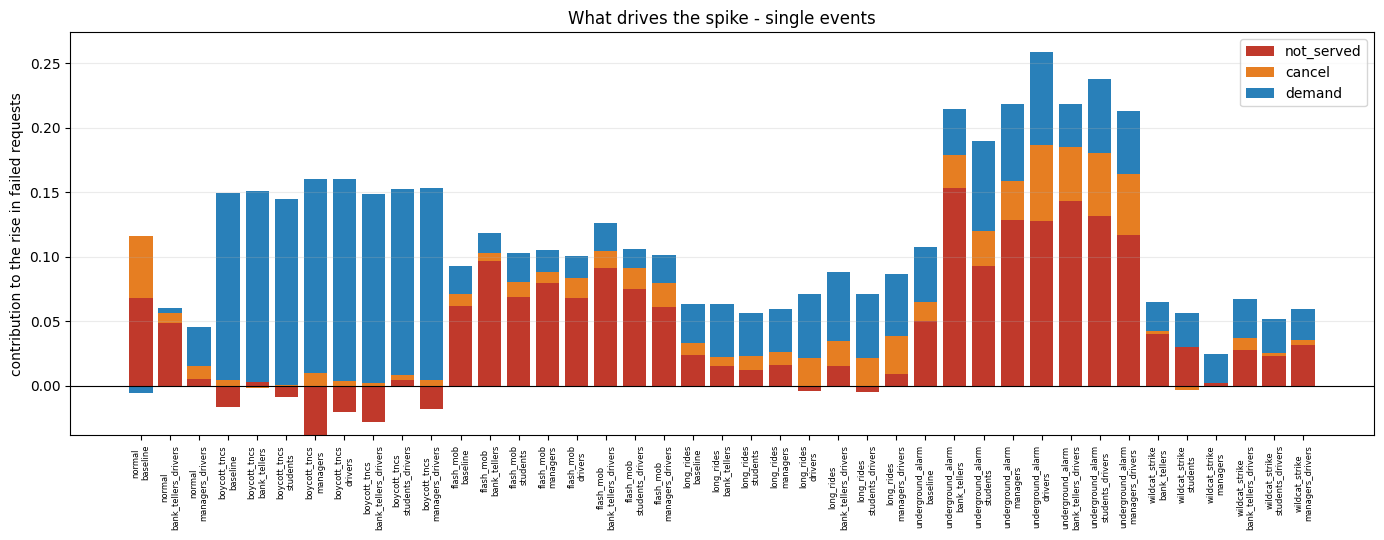

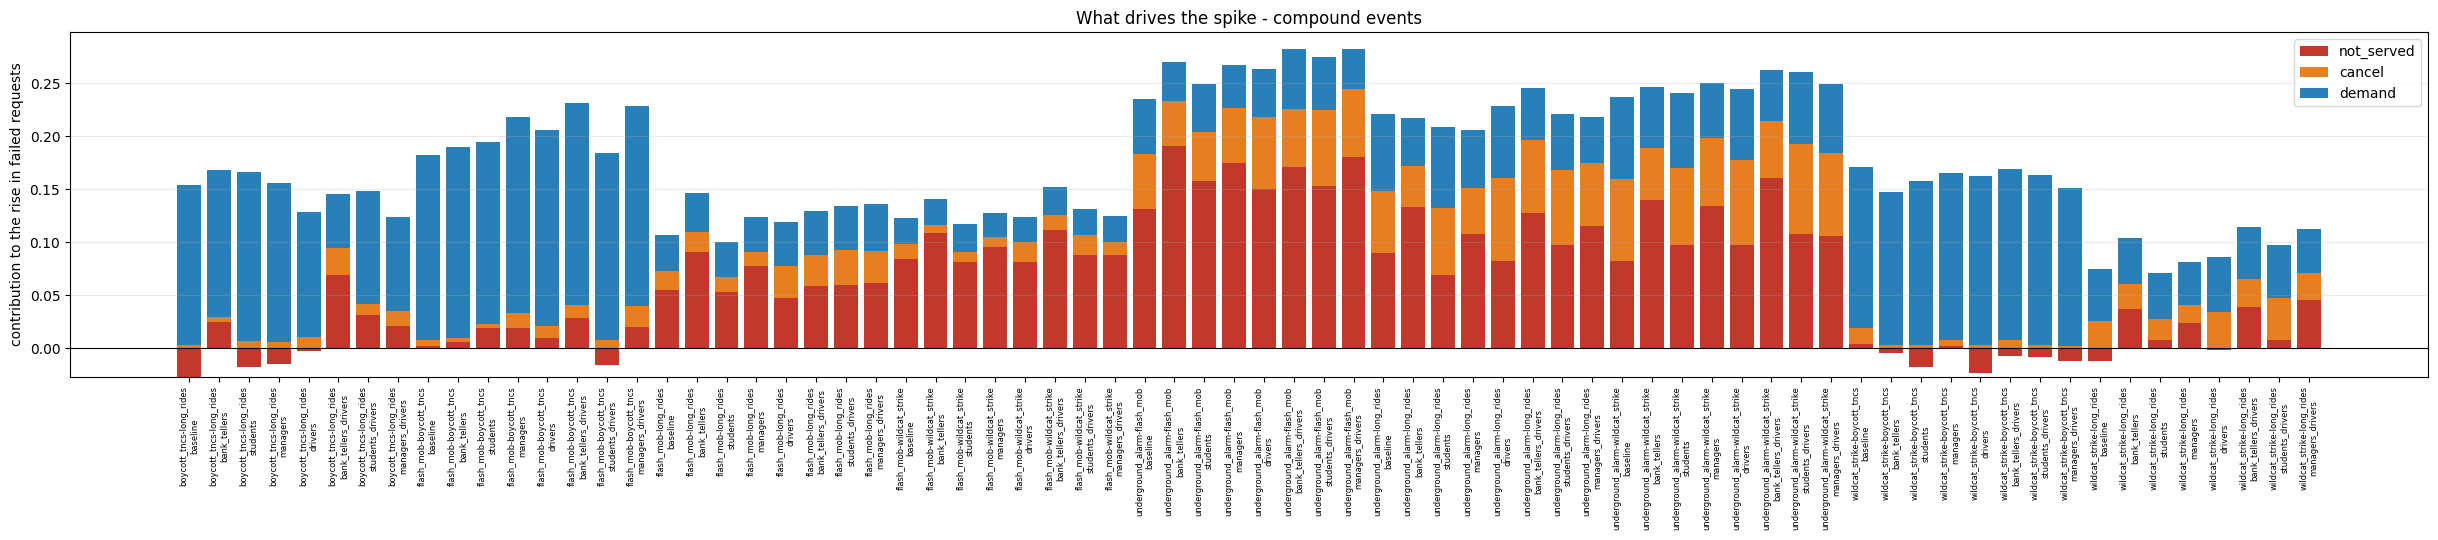

In [15]:
def plot_decomposition(scenarios: list[str], title: str, filename: str, save: bool = True):
    if cell_decomposition.empty:
        print("nothing to plot: no spikes")
        return
    sub = cell_decomposition[cell_decomposition.scenario.isin(scenarios)]
    sub = sub.dropna(subset=list(DRIVER_LABELS))
    if sub.empty:
        return
    piv = sub.set_index(["scenario", "personality"])[list(DRIVER_LABELS)]
    piv = piv.reindex(sorted(piv.index, key=lambda k: (SCENARIOS.index(k[0]),
                                                       PERSONALITIES.index(k[1]))))
    x = np.arange(len(piv))
    fig, ax = plt.subplots(figsize=(max(10, 0.34 * len(piv)), 5.5))
    bottom_pos = np.zeros(len(piv))
    bottom_neg = np.zeros(len(piv))
    colors = {"d_not_served": "#c0392b", "d_cancel": "#e67e22", "d_demand": "#2980b9"}
    for col in DRIVER_LABELS:
        v = np.nan_to_num(piv[col].to_numpy())
        pos, neg = np.clip(v, 0, None), np.clip(v, None, 0)
        ax.bar(x, pos, bottom=bottom_pos, color=colors[col], label=DRIVER_LABELS[col], width=0.8)
        ax.bar(x, neg, bottom=bottom_neg, color=colors[col], width=0.8)
        bottom_pos += pos
        bottom_neg += neg
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x, [f"{s}\n{p}" for s, p in piv.index], rotation=90, fontsize=6)
    ax.set_ylabel("contribution to the rise in failed requests")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    if save:
        plt.savefig(OUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_decomposition([REFERENCE_SCENARIO] + SINGLE_SCENARIOS,
                   "What drives the spike - single events", "spike_decomposition_single.png")
plot_decomposition(COMPOUND_SCENARIOS,
                   "What drives the spike - compound events", "spike_decomposition_compound.png")

## 5. Decomposition across the grid

In [16]:
WINDOW_METRICS = FR_COMPONENTS + ["failed_requests"]

window_rows = []
for (pers, scen), df in runs.items():
    start, end = event_window(scen)
    ts = df["timestamp"].to_numpy()
    segments = {"pre": window_mask(ts, start - 3600, start),
                "during": window_mask(ts, start, end),
                "post": window_mask(ts, end, end + 3600)}
    for m in WINDOW_METRICS:
        row = {"scenario": scen, "personality": pers, "metric": m}
        for name, mask in segments.items():
            row[name] = float(df.loc[mask, m].mean()) if mask.any() else np.nan
        row["reaction"] = row["during"] - row["pre"]
        window_rows.append(row)

window_levels = pd.DataFrame(window_rows)
base_reaction = (window_levels[window_levels.personality == BASELINE]
                 .set_index(["scenario", "metric"])["reaction"])
window_levels["did_vs_baseline"] = window_levels.apply(
    lambda r: r["reaction"] - base_reaction.get((r["scenario"], r["metric"]), np.nan), axis=1)
window_levels.to_csv(OUT_DIR / "event_window_levels.csv", index=False)
for m in WINDOW_METRICS:
    sub = window_levels[window_levels.metric == m]
    print(f"\n{m} level during the event:")
    display(sub.pivot(index="personality", columns="scenario", values="during")
            .reindex(index=PERSONALITIES, columns=SCENARIOS).round(4).rename_axis(columns="event"))


rides_not_served level during the event:


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,0.3963,0.1407,0.5473,0.3987,0.5913,0.4305,0.1780,0.2717,0.5519,0.6367,0.7520,0.7657,0.5929,0.1617,0.4619
bank_tellers,0.4088,0.1653,0.6129,0.4805,0.7035,0.5532,0.2262,0.2898,0.6376,0.6942,0.8681,0.8250,0.7602,0.1513,0.5256
students,0.4389,0.1694,0.5661,0.4366,0.5963,0.4478,0.1971,0.2795,0.5614,0.6205,0.8149,0.7333,0.6499,0.1724,0.4885
managers,0.4446,0.1591,0.5864,0.4742,0.6652,0.5059,0.2130,0.3117,0.6080,0.6300,0.7996,0.8136,0.7417,0.1885,0.5367
drivers,0.4068,0.1657,0.6014,0.4516,0.5754,0.4284,0.1862,0.2821,0.5623,0.6122,0.7374,0.7537,0.6519,0.1651,0.4525
bank_tellers_drivers,0.4551,0.1529,0.6509,0.5009,0.7024,0.5168,0.2139,0.2958,0.6124,0.6942,0.8840,0.8443,0.7688,0.2195,0.5479
students_drivers,0.4012,0.1489,0.5744,0.4656,0.6290,0.4389,0.1985,0.2538,0.5827,0.6400,0.7626,0.7448,0.6402,0.1630,0.4621
managers_drivers,0.4543,0.1819,0.5839,0.4799,0.6709,0.4590,0.2165,0.3042,0.6320,0.6338,0.8162,0.8084,0.7078,0.1674,0.5443



passengers_cancel level during the event:


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,0.0999,0.0290,0.0586,0.0702,0.0657,0.0535,0.0264,0.0357,0.0807,0.0842,0.0806,0.2037,0.1009,0.0382,0.0988
bank_tellers,0.0613,0.0271,0.0579,0.0655,0.0659,0.0501,0.0299,0.0389,0.0865,0.0514,0.0695,0.1455,0.0921,0.0261,0.0777
students,0.0510,0.0328,0.0548,0.0649,0.0634,0.0469,0.0323,0.0341,0.0851,0.0720,0.0957,0.2050,0.1054,0.0334,0.0794
managers,0.0642,0.0287,0.0541,0.0650,0.0563,0.0466,0.0300,0.0458,0.0755,0.0701,0.0865,0.1675,0.1074,0.0282,0.0865
drivers,0.0533,0.0336,0.0646,0.1075,0.0770,0.0524,0.0411,0.0502,0.1237,0.0844,0.0861,0.2693,0.1187,0.0308,0.1205
bank_tellers_drivers,0.0590,0.0308,0.0604,0.1019,0.0718,0.0536,0.0428,0.0504,0.1156,0.0734,0.0987,0.2446,0.1032,0.0370,0.1067
students_drivers,0.0579,0.0330,0.0567,0.0986,0.0784,0.0529,0.0402,0.0484,0.1289,0.0735,0.0977,0.2452,0.1241,0.0334,0.1096
managers_drivers,0.0561,0.0378,0.0636,0.0899,0.0722,0.0485,0.0416,0.0547,0.1243,0.0638,0.0950,0.2144,0.1289,0.0334,0.0972



passengers_new level during the event:


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,2.8048,1.2831,2.8041,2.6085,3.6771,2.8406,1.7600,1.2954,2.6090,2.8329,3.6749,2.9697,3.5295,1.2800,2.6085
bank_tellers,2.8055,1.2820,2.8051,2.6112,3.6749,2.8401,1.7602,1.2962,2.6075,2.8329,3.6735,2.9711,3.5275,1.2806,2.6086
students,2.8066,1.2827,2.8059,2.6107,3.6733,2.8396,1.7603,1.2934,2.6085,2.8315,3.6771,2.9717,3.5286,1.2800,2.6075
managers,2.8053,1.2820,2.8057,2.6099,3.6764,2.8400,1.7596,1.2948,2.6076,2.8347,3.6755,2.9709,3.5297,1.2806,2.6091
drivers,2.8061,1.2824,2.8065,2.6110,3.6732,2.8417,1.7608,1.2947,2.6076,2.8329,3.6767,2.9722,3.5301,1.2810,2.6088
bank_tellers_drivers,2.8046,1.2816,2.8070,2.6108,3.6747,2.8395,1.7607,1.2937,2.6088,2.8319,3.6767,2.9710,3.5302,1.2808,2.6085
students_drivers,2.8050,1.2819,2.8052,2.6091,3.6720,2.8414,1.7607,1.2955,2.6089,2.8327,3.6759,2.9701,3.5288,1.2814,2.6086
managers_drivers,2.8037,1.2819,2.8056,2.6113,3.6744,2.8421,1.7601,1.2944,2.6072,2.8326,3.6747,2.9714,3.5270,1.2807,2.6086



failed_requests level during the event:


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,0.1769,0.1152,0.2163,0.1827,0.1774,0.1704,0.1107,0.2228,0.2446,0.2552,0.2252,0.3558,0.2023,0.1378,0.2185
bank_tellers,0.1676,0.1326,0.2394,0.2118,0.2082,0.2127,0.1372,0.2370,0.2800,0.2639,0.2532,0.3485,0.2478,0.1196,0.2367
students,0.1745,0.1386,0.2215,0.1946,0.1789,0.1744,0.1252,0.2256,0.2497,0.2452,0.2461,0.3425,0.2206,0.1440,0.2215
managers,0.1814,0.1298,0.2285,0.2087,0.1952,0.1947,0.1289,0.2612,0.2628,0.2477,0.2393,0.3572,0.2466,0.1505,0.2424
drivers,0.1639,0.1372,0.2375,0.2176,0.1769,0.1692,0.1192,0.2412,0.2666,0.2468,0.2221,0.3745,0.2238,0.1360,0.2241
bank_tellers_drivers,0.1834,0.1259,0.2537,0.2355,0.2092,0.2011,0.1361,0.2533,0.2813,0.2719,0.2651,0.3958,0.2530,0.1806,0.2564
students_drivers,0.1637,0.1226,0.2252,0.2191,0.1917,0.1733,0.1274,0.2182,0.2767,0.2527,0.2323,0.3614,0.2228,0.1369,0.2241
managers_drivers,0.1821,0.1551,0.2310,0.2221,0.2009,0.1788,0.1372,0.2624,0.2931,0.2469,0.2460,0.3711,0.2444,0.1394,0.2501


## 6. Event, personality, or their interaction

For any metric `m` averaged over the event window, write `mu(p, s)` for the level in the run with personality `p` under event `s`. 

```
total(p, s)        = mu(p, s)    - mu(baseline, normal)
event(s)           = mu(base, s) - mu(baseline, normal)
personality(p)     = mu(p, norm) - mu(baseline, normal)
interaction(p, s)  = mu(p, s) - mu(base, s) - mu(p, norm) + mu(baseline, normal)
```

Effects are also reported as robust z-scores, dividing by `1.4826 * MAD` of the metric on the reference run, so metrics on different units can be ranked against each other.

In [17]:
ATTRIB_METRICS = sorted(set(metric_cols) | {"failed_requests"})
NOT_A_CAUSE = set(FR_COMPONENTS) | {"failed_requests"}

def cause_rows(frame: pd.DataFrame) -> pd.DataFrame:
    return frame[~frame.metric.isin(NOT_A_CAUSE)]

ref_df = runs[REF_KEY]
metric_scale = {}
for m in ATTRIB_METRICS:
    v = ref_df[m].to_numpy(dtype=float)
    mad = float(np.nanmedian(np.abs(v - np.nanmedian(v))))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 0:
        scale = float(np.nanstd(v))
    metric_scale[m] = scale if np.isfinite(scale) and scale > 0 else np.nan

def window_means(pers: str, scen: str, start: float, end: float) -> pd.Series:
    df = runs.get((pers, scen))
    if df is None:
        return pd.Series(np.nan, index=ATTRIB_METRICS)
    mask = window_mask(df["timestamp"].to_numpy(), start, end)
    if not mask.any():
        return pd.Series(np.nan, index=ATTRIB_METRICS)
    return df.loc[mask, ATTRIB_METRICS].mean()

attrib_rows = []
for scen in SCENARIOS:
    start, end = event_window(scen)
    if (BASELINE, scen) not in runs:
        print(f"No baseline run for '{scen}' - its cells cannot be attributed")
        continue
    mu_base_ref = window_means(BASELINE, REFERENCE_SCENARIO, start, end)
    mu_base_scen = window_means(BASELINE, scen, start, end)
    for pers in PERSONALITIES:
        if (pers, scen) not in runs or (pers, REFERENCE_SCENARIO) not in runs:
            continue
        mu_cell = window_means(pers, scen, start, end)
        mu_pers_ref = window_means(pers, REFERENCE_SCENARIO, start, end)
        for m in ATTRIB_METRICS:
            base = mu_base_ref[m]
            scen_eff = mu_base_scen[m] - base
            pers_eff = mu_pers_ref[m] - base
            total = mu_cell[m] - base
            attrib_rows.append({
                "scenario": scen, "personality": pers, "metric": m, "family": family_of(m),
                "is_compound": is_compound(scen),
                "level": mu_cell[m], "reference_level": base,
                "scenario_effect": scen_eff, "personality_effect": pers_eff,
                "interaction_effect": total - scen_eff - pers_eff, "total_effect": total,
                "scale": metric_scale.get(m, np.nan),
            })

attribution = pd.DataFrame(attrib_rows)
for col in ["scenario_effect", "personality_effect", "interaction_effect", "total_effect"]:
    attribution[f"{col}_z"] = attribution[col] / attribution["scale"]
# The two contrasts the rest of the notebook uses:
#   scen_dev = mu(p,s) - mu(p,normal)   what the event does to this personality
#   pers_dev = mu(p,s) - mu(baseline,s) what this personality does under this event
attribution["scen_dev"] = attribution["scenario_effect"] + attribution["interaction_effect"]
attribution["scen_dev_z"] = attribution["scenario_effect_z"] + attribution["interaction_effect_z"]
attribution["pers_dev"] = attribution["personality_effect"] + attribution["interaction_effect"]
attribution["pers_dev_z"] = attribution["personality_effect_z"] + attribution["interaction_effect_z"]
attribution.to_csv(OUT_DIR / "attribution.csv", index=False)
print(f"Attribution: {len(attribution)} rows "
      f"({attribution.metric.nunique()} metrics x "
      f"{attribution.groupby(['scenario', 'personality']).ngroups} cells)")

Attribution: 6720 rows (56 metrics x 120 cells)



Failed_requests, event effect


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,0.0,-0.038,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.073
bank_tellers,0.0,-0.038,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.073
students,0.0,-0.038,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.073
managers,0.0,-0.038,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.073
drivers,0.0,-0.038,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.073
bank_tellers_drivers,0.0,-0.038,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.073
students_drivers,0.0,-0.038,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.073
managers_drivers,0.0,-0.038,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.073



Failed_requests, personality effect


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
bank_tellers,-0.0094,0.0137,-0.0094,0.0085,0.0055,0.0137,0.0085,0.0137,0.0085,0.0137,0.0055,0.0085,0.0137,0.0137,0.0085
students,-0.0024,0.0082,-0.0024,0.0011,0.0045,0.0082,0.0011,0.0082,0.0011,0.0082,0.0045,0.0011,0.0082,0.0082,0.0011
managers,0.0045,0.0190,0.0045,0.0116,0.0153,0.0190,0.0116,0.0190,0.0116,0.0190,0.0153,0.0116,0.0190,0.0190,0.0116
drivers,-0.0130,0.0030,-0.0130,0.0081,-0.0018,0.0030,0.0081,0.0030,0.0081,0.0030,-0.0018,0.0081,0.0030,0.0030,0.0081
bank_tellers_drivers,0.0065,0.0364,0.0065,0.0340,0.0169,0.0364,0.0340,0.0364,0.0340,0.0364,0.0169,0.0340,0.0364,0.0364,0.0340
students_drivers,-0.0132,0.0103,-0.0132,0.0140,0.0025,0.0103,0.0140,0.0103,0.0140,0.0103,0.0025,0.0140,0.0103,0.0103,0.0140
managers_drivers,0.0052,0.0232,0.0052,0.0321,0.0169,0.0232,0.0321,0.0232,0.0321,0.0232,0.0169,0.0321,0.0232,0.0232,0.0321



Failed_requests, interaction effect


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
bank_tellers,0.0,0.0037,0.0325,0.0206,0.0252,0.0286,0.0180,0.0005,0.0269,-0.0050,0.0225,-0.0158,0.0317,-0.0319,0.0098
students,0.0,0.0153,0.0076,0.0107,-0.0030,-0.0041,0.0135,-0.0054,0.0040,-0.0182,0.0164,-0.0145,0.0101,-0.0020,0.0019
managers,0.0,-0.0044,0.0077,0.0144,0.0025,0.0053,0.0066,0.0194,0.0066,-0.0266,-0.0012,-0.0102,0.0253,-0.0064,0.0123
drivers,0.0,0.0190,0.0342,0.0267,0.0012,-0.0042,0.0004,0.0154,0.0138,-0.0114,-0.0012,0.0105,0.0184,-0.0048,-0.0025
bank_tellers_drivers,0.0,-0.0256,0.0310,0.0188,0.0148,-0.0057,-0.0085,-0.0059,0.0027,-0.0197,0.0230,0.0060,0.0142,0.0064,0.0040
students_drivers,0.0,-0.0029,0.0221,0.0223,0.0117,-0.0074,0.0027,-0.0149,0.0180,-0.0128,0.0046,-0.0085,0.0103,-0.0112,-0.0083
managers_drivers,0.0,0.0168,0.0095,0.0073,0.0066,-0.0147,-0.0055,0.0164,0.0163,-0.0314,0.0039,-0.0169,0.0190,-0.0216,-0.0004



Failed_requests, total effect


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
baseline,0.0000,-0.0380,0.0394,0.0373,0.0155,0.0173,-0.0348,0.0697,0.0992,0.1021,0.0632,0.2104,0.0492,-0.0153,0.0730
bank_tellers,-0.0094,-0.0206,0.0625,0.0664,0.0462,0.0596,-0.0083,0.0838,0.1346,0.1108,0.0912,0.2031,0.0946,-0.0335,0.0913
students,-0.0024,-0.0145,0.0446,0.0491,0.0169,0.0213,-0.0202,0.0724,0.1042,0.0920,0.0841,0.1970,0.0675,-0.0091,0.0761
managers,0.0045,-0.0233,0.0516,0.0633,0.0333,0.0416,-0.0165,0.1081,0.1174,0.0945,0.0774,0.2118,0.0935,-0.0026,0.0970
drivers,-0.0130,-0.0160,0.0605,0.0721,0.0149,0.0161,-0.0262,0.0881,0.1211,0.0936,0.0602,0.2291,0.0706,-0.0171,0.0787
bank_tellers_drivers,0.0065,-0.0272,0.0768,0.0901,0.0473,0.0479,-0.0093,0.1001,0.1359,0.1188,0.1032,0.2504,0.0998,0.0274,0.1110
students_drivers,-0.0132,-0.0305,0.0482,0.0737,0.0298,0.0202,-0.0180,0.0650,0.1312,0.0996,0.0704,0.2159,0.0697,-0.0162,0.0787
managers_drivers,0.0052,0.0020,0.0540,0.0767,0.0390,0.0257,-0.0082,0.1092,0.1476,0.0938,0.0841,0.2257,0.0913,-0.0137,0.1047


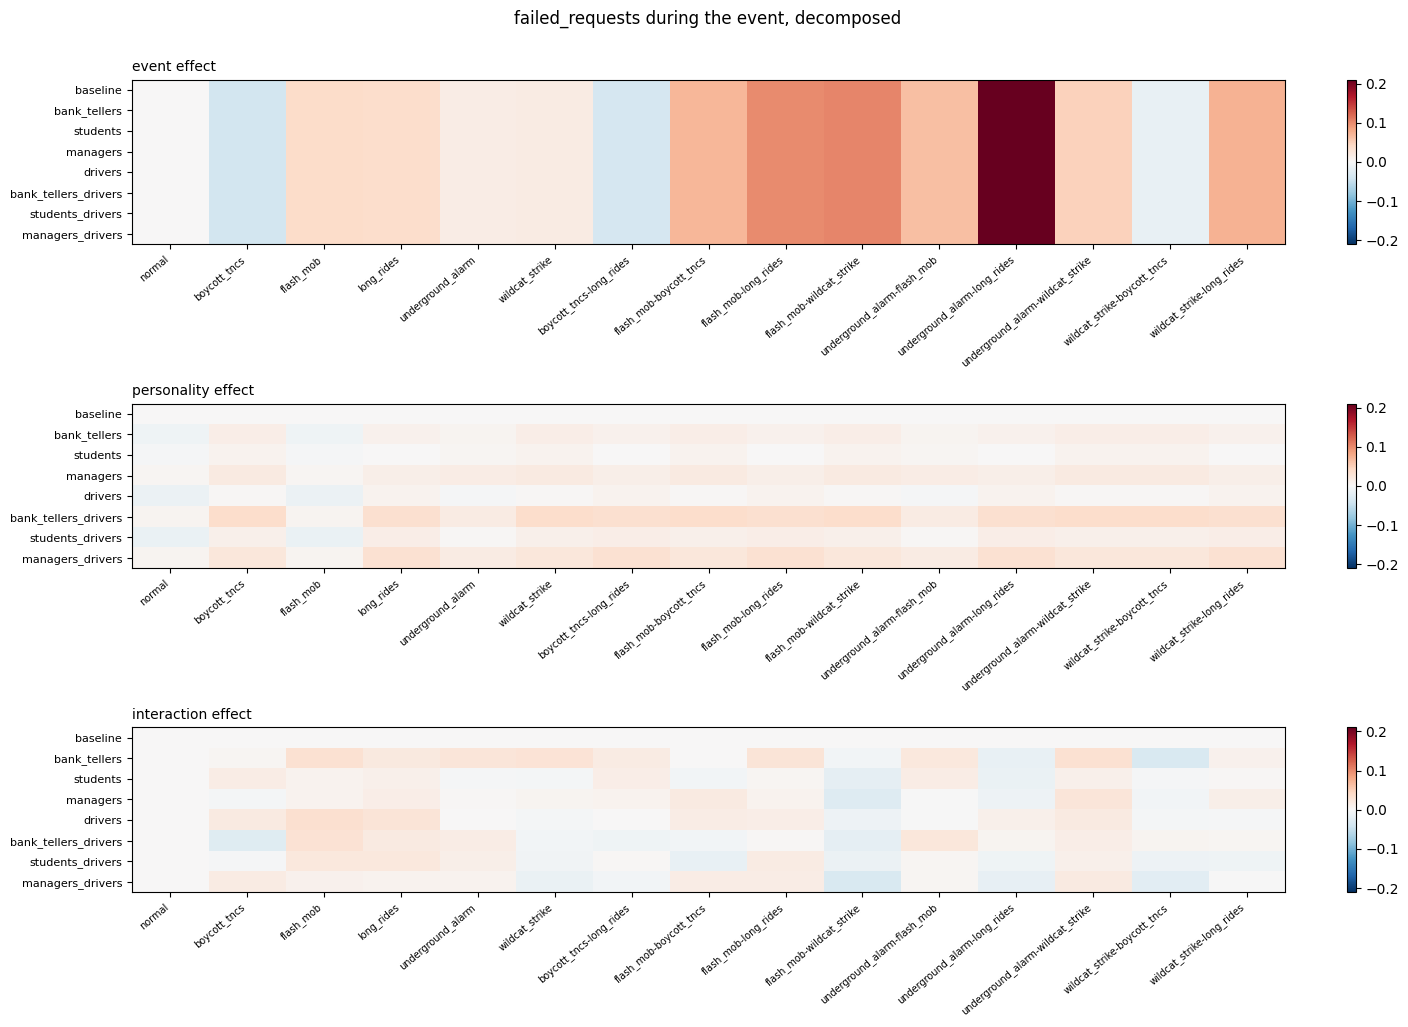

In [18]:
fr_attrib = attribution[attribution.metric == "failed_requests"].copy()
fr_attrib.to_csv(OUT_DIR / "attribution_failed_requests.csv", index=False)

for col, label in [("scenario_effect", "event"), ("personality_effect", "personality"),
                   ("interaction_effect", "interaction"), ("total_effect", "total")]:
    print(f"\nFailed_requests, {label} effect")
    display(fr_attrib.pivot(index="personality", columns="scenario", values=col)
            .reindex(index=PERSONALITIES, columns=SCENARIOS).round(4).rename_axis(columns="event"))

def plot_fr_attribution(save: bool = True):
    if fr_attrib.empty:
        return
    cols = [("scenario_effect", "event"), ("personality_effect", "personality"),
            ("interaction_effect", "interaction")]
    mats = [fr_attrib.pivot(index="personality", columns="scenario", values=c)
            .reindex(index=PERSONALITIES, columns=SCENARIOS) for c, _ in cols]
    lim = max((np.nanmax(np.abs(m.to_numpy())) for m in mats), default=1.0)
    lim = lim if np.isfinite(lim) and lim > 0 else 1.0
    fig, axes = plt.subplots(len(cols), 1, figsize=(0.55 * len(SCENARIOS) + 6, 3.4 * len(cols)), squeeze=False)
    for ax, piv, (_, label) in zip(axes[:, 0], mats, cols):
        im = ax.imshow(piv.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
        ax.set_xticks(range(piv.shape[1]), piv.columns, rotation=40, ha="right", fontsize=7)
        ax.set_yticks(range(piv.shape[0]), piv.index, fontsize=8)
        ax.set_title(f"{label} effect", fontsize=10, loc="left")
        fig.colorbar(im, ax=ax, fraction=0.02)
    fig.suptitle("failed_requests during the event, decomposed", y=1.002)
    plt.tight_layout()
    if save:
        plt.savefig(OUT_DIR / "attribution_failed_requests.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_fr_attribution()

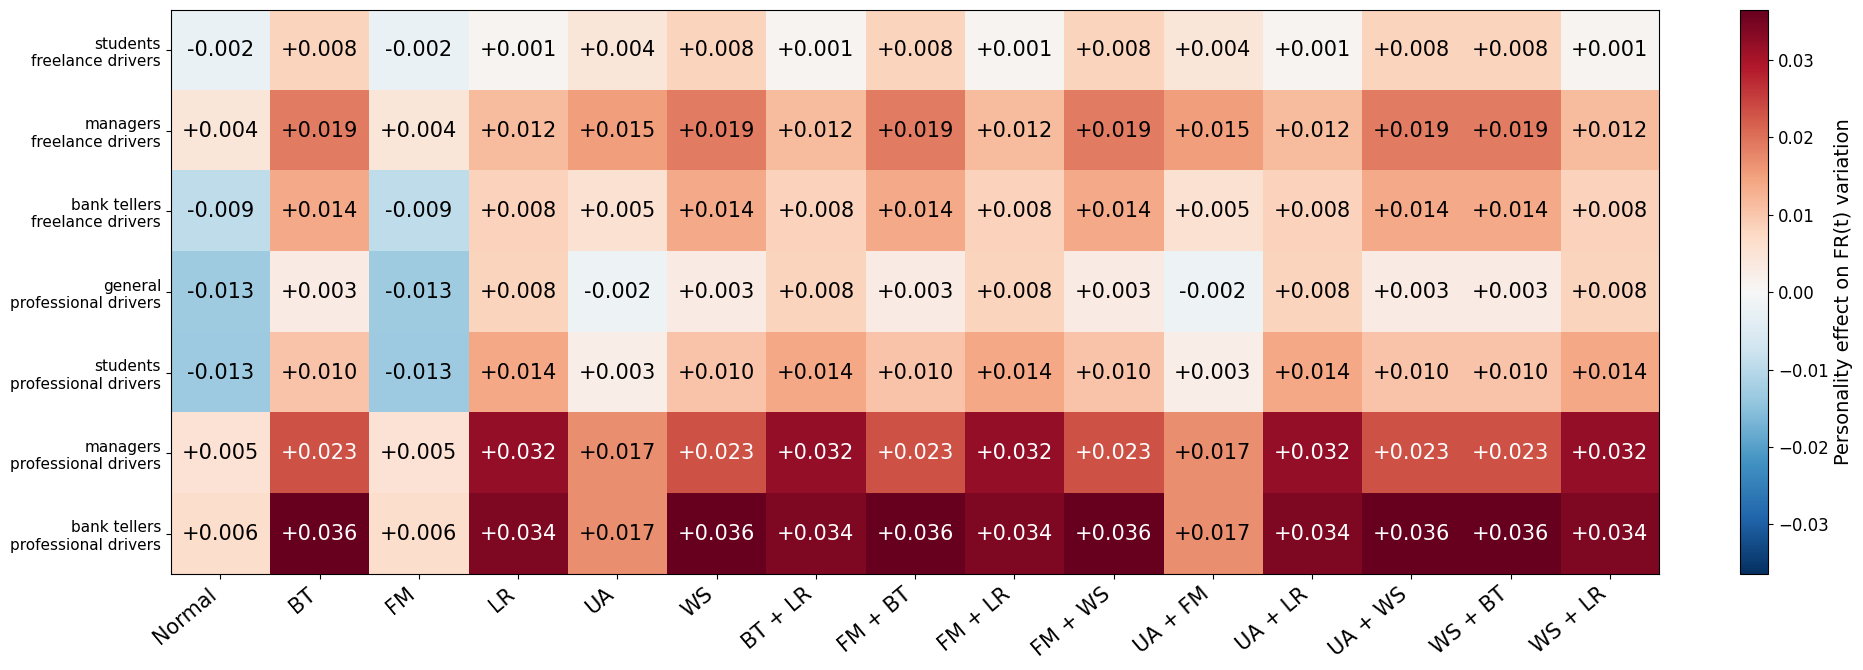

In [19]:
POPULATIONS = ["baseline", "students", "managers", "bank_tellers", "drivers", 
                     "students_drivers", "managers_drivers", "bank_tellers_drivers"]
POPULATION_LABEL = {"baseline": "general\nfreelance drivers",
                    "students": "students\nfreelance drivers",
                    "managers": "managers\nfreelance drivers",
                    "bank_tellers": "bank tellers\nfreelance drivers",
                    "drivers": "general\nprofessional drivers",
                    "students_drivers": "students\nprofessional drivers",
                    "managers_drivers": "managers\nprofessional drivers",
                    "bank_tellers_drivers": "bank tellers\nprofessional drivers"}
EVENT_ABBR = {"underground_alarm": "UA", "wildcat_strike": "WS", "flash_mob": "FM",
              "long_rides": "LR", "boycott_tncs": "BT"}

def scenario_label(scen: str) -> str:
    return "Normal" if scen == REFERENCE_SCENARIO else " + ".join(EVENT_ABBR[c] for c in scen.split("-"))

fig_pers = POPULATIONS[1:]
piv = (fr_attrib.pivot(index="personality", columns="scenario", values="personality_effect")
       .reindex(index=fig_pers, columns=SCENARIOS))
lim = float(np.nanmax(np.abs(piv.to_numpy())))
fig, ax = plt.subplots(figsize=(0.85 * len(SCENARIOS) + 6, 6.8))
im = ax.imshow(piv.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(piv.shape[1]), [scenario_label(s) for s in piv.columns],
              rotation=40, ha="right", fontsize=15)
ax.set_yticks(range(piv.shape[0]), [POPULATION_LABEL[p] for p in piv.index], fontsize=11)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=15,
                    color="white" if abs(v) > 0.6 * lim else "black")
bar = fig.colorbar(im, ax=ax, fraction=0.025)
bar.set_label("Personality effect on FR(t) variation", fontsize=14)
bar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "attribution_failed_requests.pdf", dpi=300, bbox_inches="tight")
plt.show()

`event_causes` are what the event does regardless of who is in the system;
`personality_causes` are what the configuration does regardless of the event;
`interaction_causes` are the metrics that only misbehave when this configuration meets this event, which is where genuinely emergent failure lives.

In [20]:
def rank_causes(effect_col: str, top_k: int = TOP_K) -> pd.DataFrame:
    sub = cause_rows(attribution).copy()
    if effect_col in ("scenario_effect", "interaction_effect"):
        sub = sub[sub.scenario != REFERENCE_SCENARIO]
    if effect_col in ("personality_effect", "interaction_effect"):
        sub = sub[sub.personality != BASELINE]
    sub["abs_z"] = sub[f"{effect_col}_z"].abs()
    sub = sub[np.isfinite(sub["abs_z"])]
    ranked = (sub.sort_values("abs_z", ascending=False)
              .groupby(["scenario", "personality"], sort=False).head(top_k)
              .sort_values(["scenario", "personality", "abs_z"], ascending=[True, True, False]))
    return ranked[["scenario", "personality", "metric", "family", effect_col,
                   f"{effect_col}_z", "level", "reference_level"]]

cause_tables = {}
for effect_col, name in [("scenario_effect", "scenario"),
                         ("personality_effect", "personality"),
                         ("interaction_effect", "interaction")]:
    tbl = rank_causes(effect_col)
    cause_tables[name] = tbl
    tbl.to_csv(OUT_DIR / f"causes_{name}.csv", index=False)

In [21]:
def family_effect_table(effect_col: str) -> pd.DataFrame:
    sub = cause_rows(attribution).copy()
    sub["abs_z"] = sub[f"{effect_col}_z"].abs()
    return (sub.groupby(["scenario", "personality", "family"])["abs_z"].mean()
            .reset_index().rename(columns={"abs_z": effect_col}))


family_effects = None
for effect_col in ["scenario_effect", "personality_effect", "interaction_effect"]:
    t = family_effect_table(effect_col)
    family_effects = t if family_effects is None else family_effects.merge(
        t, on=["scenario", "personality", "family"], how="outer")
family_effects.to_csv(OUT_DIR / "causes_by_family.csv", index=False)
print("Mechanism families, mean |z| of the interaction effect:")
display(family_effects.pivot_table(index="scenario", columns="family", values="interaction_effect").round(2).rename_axis(index="event"))

Mechanism families, mean |z| of the interaction effect:


family,demand,driver_decisions,market,matching,passenger_decisions,passenger_experience,supply,trip
event,,,,,,,,
boycott_tncs,0.06,0.13,0.20,0.07,0.30,0.12,0.28,0.13
boycott_tncs-long_rides,0.04,0.08,0.23,0.04,0.14,0.18,0.21,0.17
flash_mob,0.10,0.16,1.05,0.07,0.20,0.18,0.25,0.21
flash_mob-boycott_tncs,0.07,0.13,0.29,0.05,0.24,0.28,0.28,0.14
flash_mob-long_rides,0.05,0.08,0.36,0.06,0.16,0.13,0.23,0.12
flash_mob-wildcat_strike,0.13,0.27,0.41,0.09,0.15,0.15,0.25,0.16
long_rides,0.03,0.09,0.41,0.04,0.12,0.08,0.18,0.21
normal,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
underground_alarm,0.12,0.16,0.34,0.08,0.17,0.16,0.23,0.15


## 7. Decombining events and personalities

In [22]:
ATTRIB_INDEXED = attribution.set_index(["scenario", "personality", "metric"]).sort_index()

# Observed deviation of the whole vs the summed deviations of its parts, per metric
def additivity(dev_col: str, whole_key: tuple[str, str], part_keys: list[tuple[str, str]]) -> pd.DataFrame | None:
    try:
        observed = ATTRIB_INDEXED.loc[whole_key, dev_col]
        observed_z = ATTRIB_INDEXED.loc[whole_key, f"{dev_col}_z"]
    except KeyError:
        return None
    expected = None
    expected_z = None
    for key in part_keys:
        try:
            part = ATTRIB_INDEXED.loc[key, dev_col]
            part_z = ATTRIB_INDEXED.loc[key, f"{dev_col}_z"]
        except KeyError:
            return None
        expected = part if expected is None else expected.add(part, fill_value=np.nan)
        expected_z = part_z if expected_z is None else expected_z.add(part_z, fill_value=np.nan)
    out = pd.DataFrame({"observed": observed, "expected": expected, "observed_z": observed_z, "expected_z": expected_z})
    out["residual"] = out["observed"] - out["expected"]
    out["residual_z"] = out["observed_z"] - out["expected_z"]
    return out.reset_index().rename(columns={"index": "metric"})

scenario_additivity_rows = []
for scen in COMPOUND_SCENARIOS:
    comps = scenario_components(scen)
    for pers in PERSONALITIES:
        res = additivity("scen_dev", (scen, pers), [(c, pers) for c in comps])
        if res is None:
            continue
        res.insert(0, "personality", pers)
        res.insert(0, "components", "+".join(comps))
        res.insert(0, "scenario", scen)
        scenario_additivity_rows.append(res)
scenario_additivity = (pd.concat(scenario_additivity_rows, ignore_index=True) if scenario_additivity_rows else pd.DataFrame())
if not scenario_additivity.empty:
    scenario_additivity.to_csv(OUT_DIR / "additivity_scenarios.csv", index=False)
    fr_add = scenario_additivity[scenario_additivity.metric == "failed_requests"]
    print("Compound events: observed vs expected effect on failed_requests:")
    display(fr_add.pivot(index="personality", columns="scenario", values="residual").reindex(index=PERSONALITIES).round(4).rename_axis(columns="event"))
    print("\nSuper-additive cells (compound worse than the sum of its parts), largest first:")
    display(fr_add.sort_values("residual", ascending=False)
            .head(15)[["scenario", "components", "personality", "observed", "expected", "residual"]].round(4).rename(columns={"scenario": "event"}))

personality_additivity_rows = []
for combo, (passenger, driver) in COMBOS.items():
    if combo not in PERSONALITIES:
        continue
    for scen in SCENARIOS:
        res = additivity("pers_dev", (scen, combo), [(scen, passenger), (scen, driver)])
        if res is None:
            continue
        res.insert(0, "parts", f"{passenger}+{driver}")
        res.insert(0, "personality", combo)
        res.insert(0, "scenario", scen)
        personality_additivity_rows.append(res)
personality_additivity = (pd.concat(personality_additivity_rows, ignore_index=True) if personality_additivity_rows else pd.DataFrame())
if not personality_additivity.empty:
    personality_additivity.to_csv(OUT_DIR / "additivity_personalities.csv", index=False)
    fr_padd = personality_additivity[personality_additivity.metric == "failed_requests"]
    print("\nCombined personalities: residual on failed_requests (obs - sum of parts):")
    display(fr_padd.pivot(index="personality", columns="scenario", values="residual").reindex(columns=SCENARIOS).round(4).rename_axis(columns="event"))

Compound events: observed vs expected effect on failed_requests:


event,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,
baseline,-0.0341,0.0683,0.0225,0.0454,0.0084,0.1576,0.0164,0.0054,0.0184
bank_tellers,-0.0404,0.0325,-0.0037,-0.0207,-0.0269,0.0959,-0.0057,-0.0588,-0.0210
students,-0.0466,0.0400,0.0081,0.0237,0.0202,0.1354,0.0337,-0.0078,0.0138
managers,-0.0374,0.0843,0.0070,0.0059,-0.0030,0.1305,0.0339,-0.0018,0.0111
drivers,-0.0793,0.0305,-0.0245,0.0040,-0.0283,0.1402,0.0378,-0.0142,-0.0065
bank_tellers_drivers,-0.0358,0.0570,-0.0246,0.0005,-0.0145,0.1299,0.0215,0.0431,0.0094
students_drivers,-0.0509,0.0341,-0.0039,0.0180,-0.0208,0.1150,0.0223,0.0045,-0.0048
managers_drivers,-0.0637,0.0584,0.0221,0.0192,-0.0038,0.1268,0.0435,-0.0182,0.0255



Super-additive cells (compound worse than the sum of its parts), largest first:


,event,components,personality,observed,expected,residual
2260,underground_alarm-long_rides,underground_alarm+long_rides,baseline,0.2104,0.0528,0.1576
2484,underground_alarm-long_rides,underground_alarm+long_rides,drivers,0.2209,0.0808,0.1402
2372,underground_alarm-long_rides,underground_alarm+long_rides,students,0.1959,0.0605,0.1354
2428,underground_alarm-long_rides,underground_alarm+long_rides,managers,0.2002,0.0697,0.1305
2540,underground_alarm-long_rides,underground_alarm+long_rides,bank_tellers_drivers,0.2164,0.0865,0.1299
2652,underground_alarm-long_rides,underground_alarm+long_rides,managers_drivers,0.1935,0.0667,0.1268
2596,underground_alarm-long_rides,underground_alarm+long_rides,students_drivers,0.2019,0.0869,0.1150
2316,underground_alarm-long_rides,underground_alarm+long_rides,bank_tellers,0.1946,0.0987,0.0959
636,flash_mob-boycott_tncs,flash_mob+boycott_tncs,managers,0.0891,0.0047,0.0843
468,flash_mob-boycott_tncs,flash_mob+boycott_tncs,baseline,0.0697,0.0014,0.0683



Combined personalities: residual on failed_requests (obs - sum of parts):


event,normal,boycott_tncs,flash_mob,long_rides,underground_alarm,wildcat_strike,boycott_tncs-long_rides,flash_mob-boycott_tncs,flash_mob-long_rides,flash_mob-wildcat_strike,underground_alarm-flash_mob,underground_alarm-long_rides,underground_alarm-wildcat_strike,wildcat_strike-boycott_tncs,wildcat_strike-long_rides
personality,,,,,,,,,,,,,,,
bank_tellers_drivers,0.0288,-0.0286,-0.0069,-0.0111,0.0016,-0.0105,-0.0097,-0.0021,-0.0207,0.0164,0.0150,0.0286,-0.0163,0.0628,0.0141
managers_drivers,0.0137,0.0033,-0.0187,-0.0214,0.0063,-0.0147,-0.0003,-0.0173,0.0082,0.0077,0.0098,-0.0048,-0.0236,-0.0093,0.0021
students_drivers,0.0022,-0.0380,-0.0176,-0.0103,0.0134,0.0000,-0.0064,-0.0258,0.0050,0.0160,-0.0107,0.0002,-0.0192,-0.0053,-0.0030


## 8. Metrics around a spike

For every cell with at least one spike, each metric is measured in three places:

- **spike**: inside the union of that cell's spike episodes,
- **lead**: the `LEAD_WINDOW_S` before each spike starts,
- **own baseline**: the same run outside spikes and outside the event.

`dev_vs_own` isolates what changed within the run, `dev_vs_reference` says whether the spike level is abnormal against `(baseline, normal)` at the same clock time, and `lead_dev` says what moved first (robust z units).

In [23]:
def masks_for_cell(pers: str, scen: str, eps: pd.DataFrame):
    df = runs[(pers, scen)]
    ts = df["timestamp"].to_numpy()
    spike = np.zeros(len(ts), dtype=bool)
    lead = np.zeros(len(ts), dtype=bool)
    for _, ep in eps.iterrows():
        spike |= window_mask(ts, ep["start_ts"], ep["end_ts"])
        lead |= window_mask(ts, ep["start_ts"] - LEAD_WINDOW_S, ep["start_ts"])
    lead &= ~spike
    ev_start, ev_end = event_window(scen)
    own_base = ~spike & ~lead & ~window_mask(ts, ev_start, ev_end)
    return df, ts, spike, lead, own_base

spike_profile_rows = []
if not spikes.empty:
    ref_by_ts = runs[REF_KEY].set_index("timestamp")
    for (scen, pers), eps in spikes.groupby(["scenario", "personality"]):
        df, ts, spike_m, lead_m, own_m = masks_for_cell(pers, scen, eps)
        if not spike_m.any():
            continue
        ref_spike = ref_by_ts.reindex(ts[spike_m]).mean(numeric_only=True)
        for m in ATTRIB_METRICS:
            scale = metric_scale.get(m, np.nan)
            spike_level = float(df.loc[spike_m, m].mean())
            own_level = float(df.loc[own_m, m].mean()) if own_m.any() else np.nan
            lead_level = float(df.loc[lead_m, m].mean()) if lead_m.any() else np.nan
            ref_level = float(ref_spike.get(m, np.nan))
            spike_profile_rows.append({
                "scenario": scen, "personality": pers, "metric": m, "family": family_of(m),
                "spike_level": spike_level, "own_baseline_level": own_level,
                "lead_level": lead_level, "reference_level": ref_level,
                "dev_vs_own": (spike_level - own_level) / scale if scale else np.nan,
                "dev_vs_reference": (spike_level - ref_level) / scale if scale else np.nan,
                "lead_dev": (lead_level - own_level) / scale if scale else np.nan,
            })

spike_profile = pd.DataFrame(spike_profile_rows)
if spike_profile.empty:
    print("no spikes to profile")
    spike_causes_ranked = pd.DataFrame()
else:
    spike_profile.to_csv(OUT_DIR / "spike_metric_profile.csv", index=False)
    ranked = spike_profile.copy()
    ranked["abs_dev"] = ranked["dev_vs_own"].abs()
    spike_causes_ranked = (ranked[np.isfinite(ranked.abs_dev) & ~ranked.metric.isin(["failed_requests"] + FR_COMPONENTS)]
                           .sort_values("abs_dev", ascending=False)
                           .groupby(["scenario", "personality"], sort=False).head(TOP_K)
                           .sort_values(["scenario", "personality", "abs_dev"], ascending=[True, True, False]))
    spike_causes_ranked.to_csv(OUT_DIR / "causes_spike.csv", index=False)

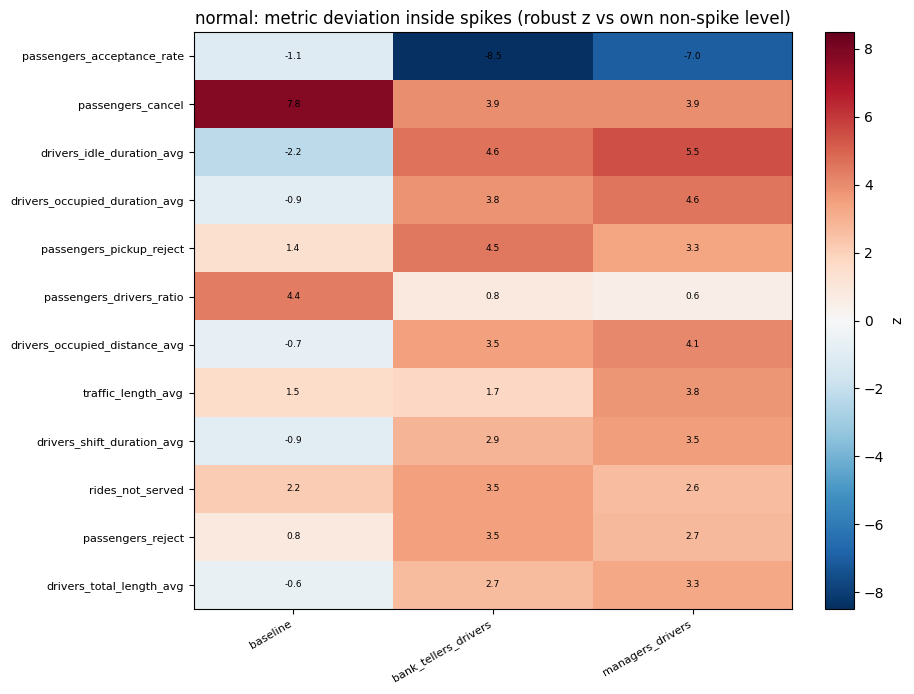

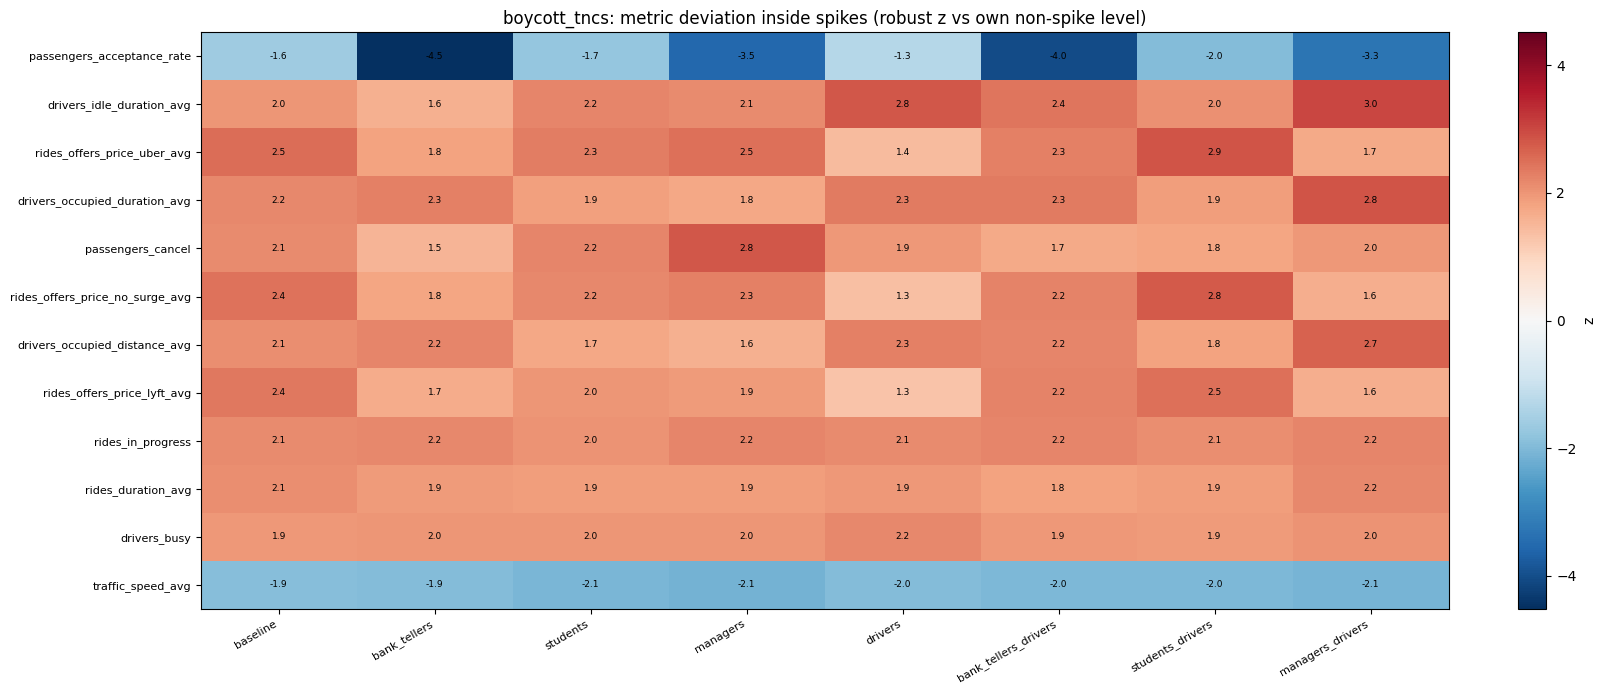

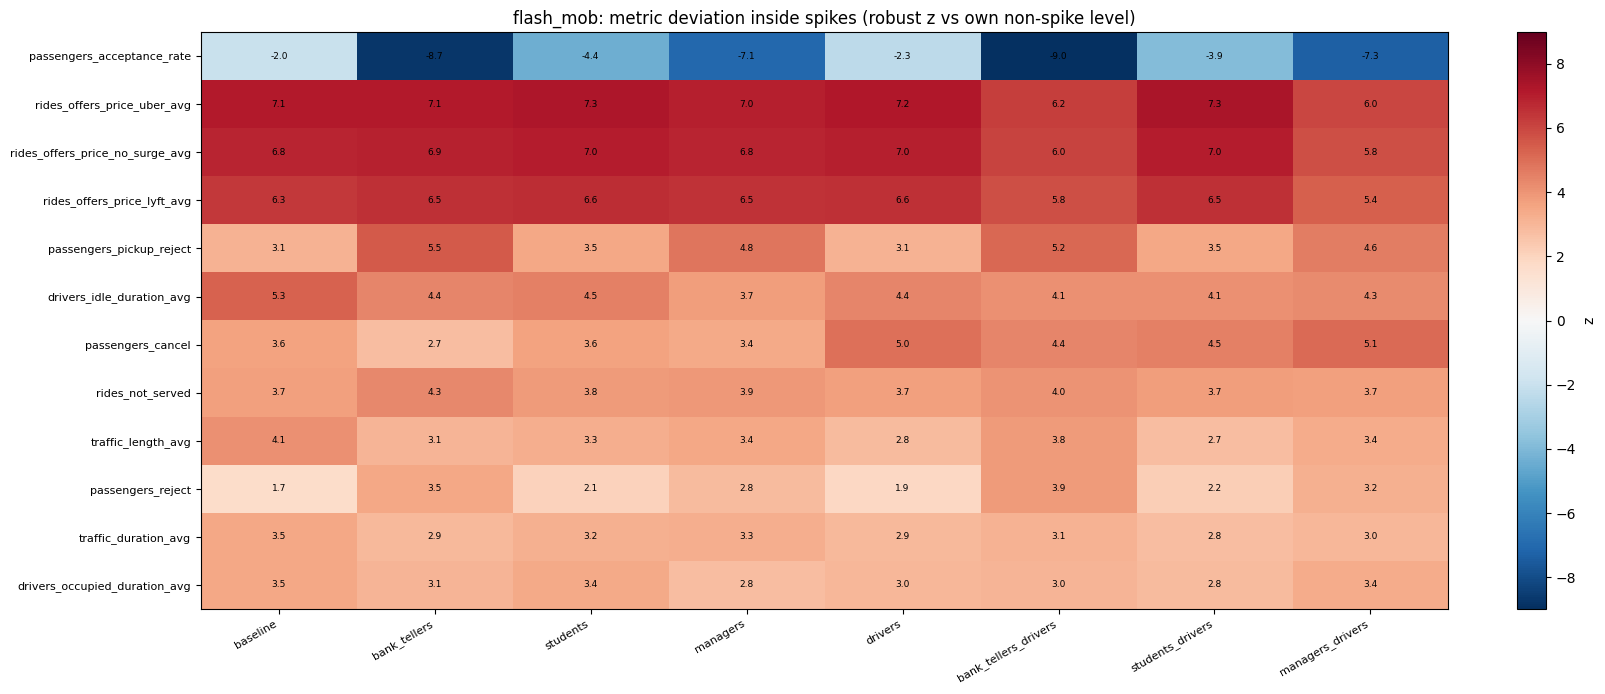

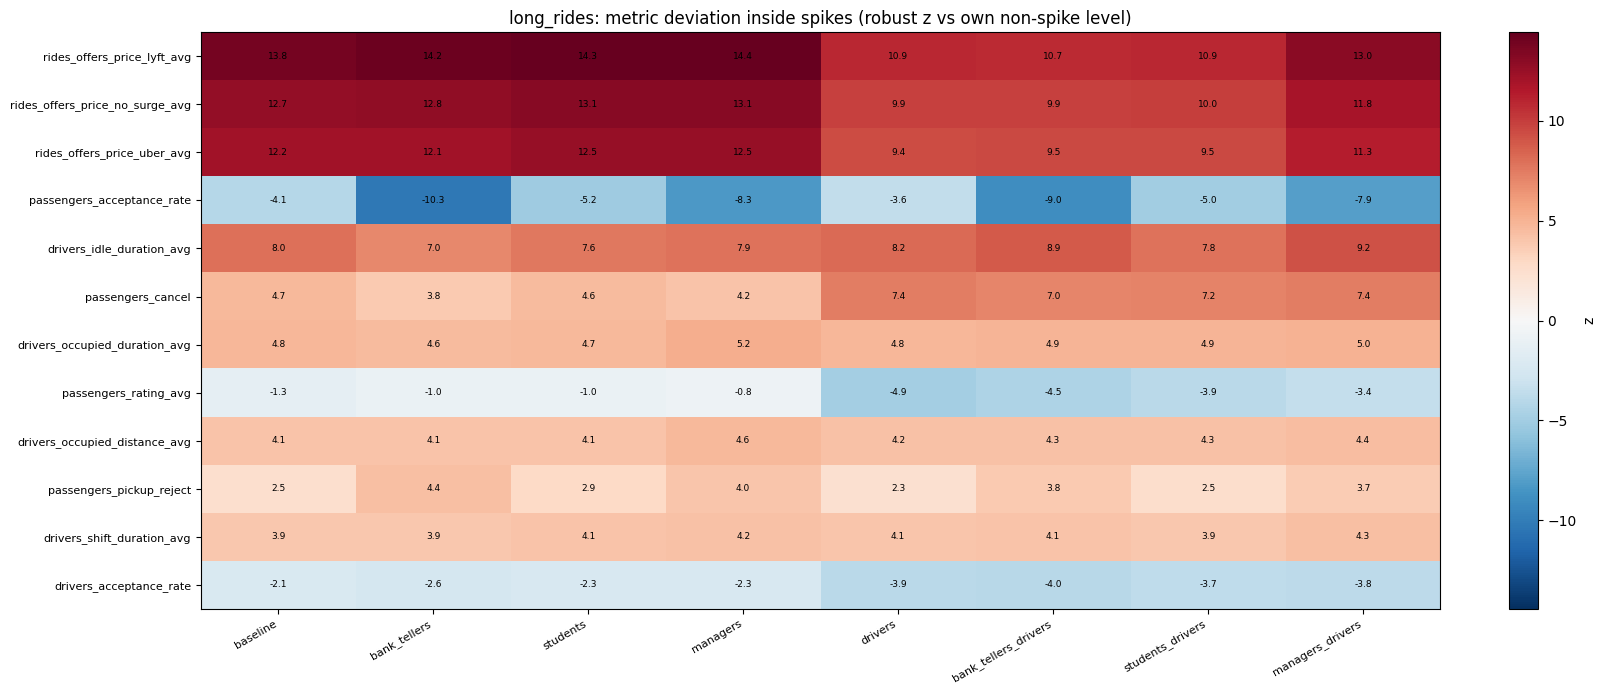

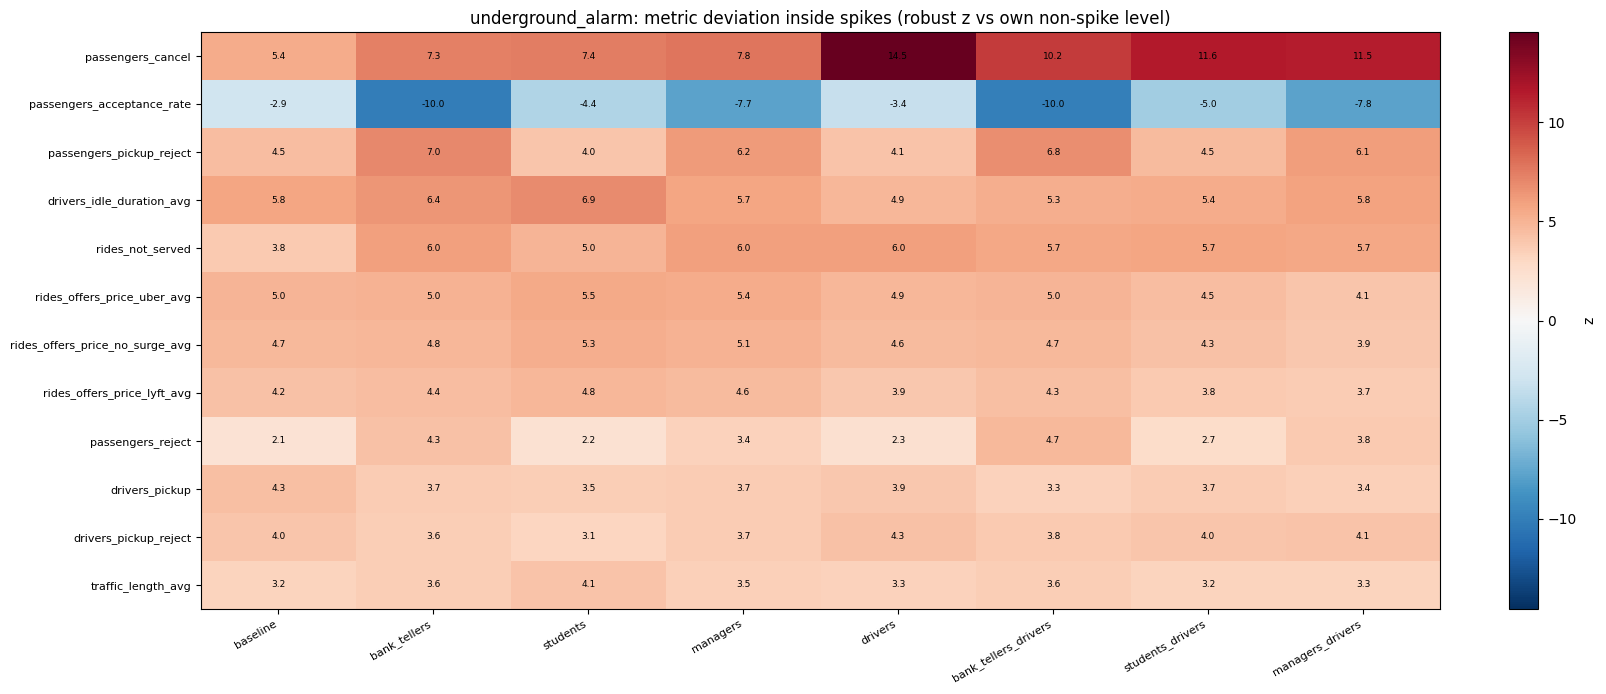

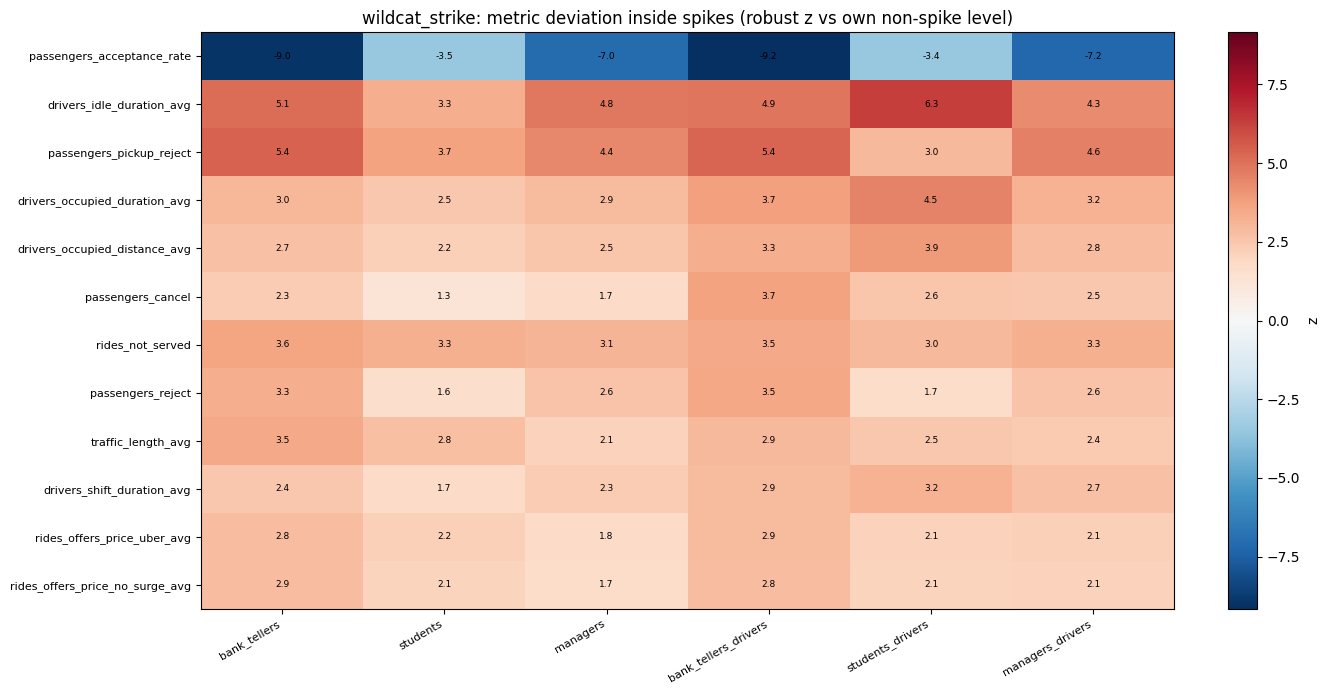

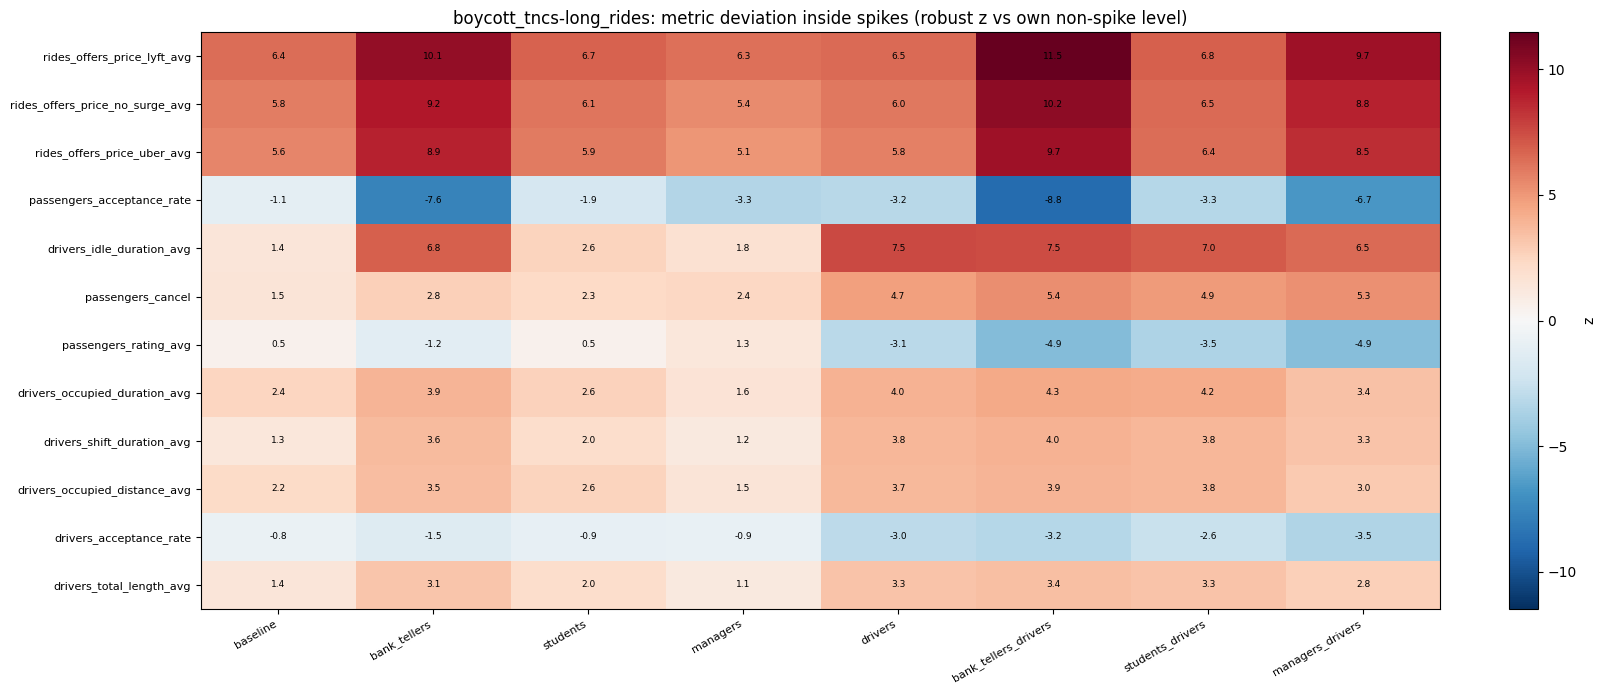

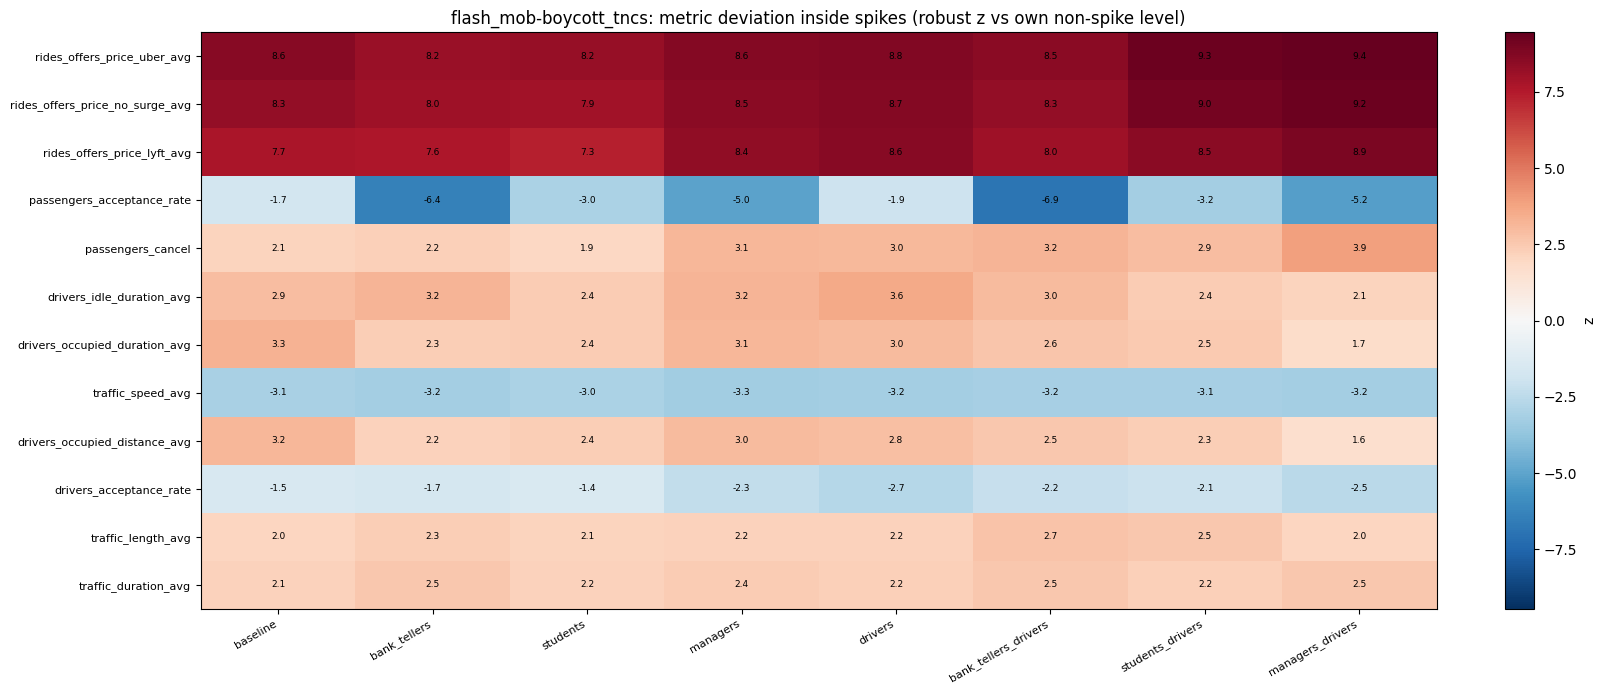

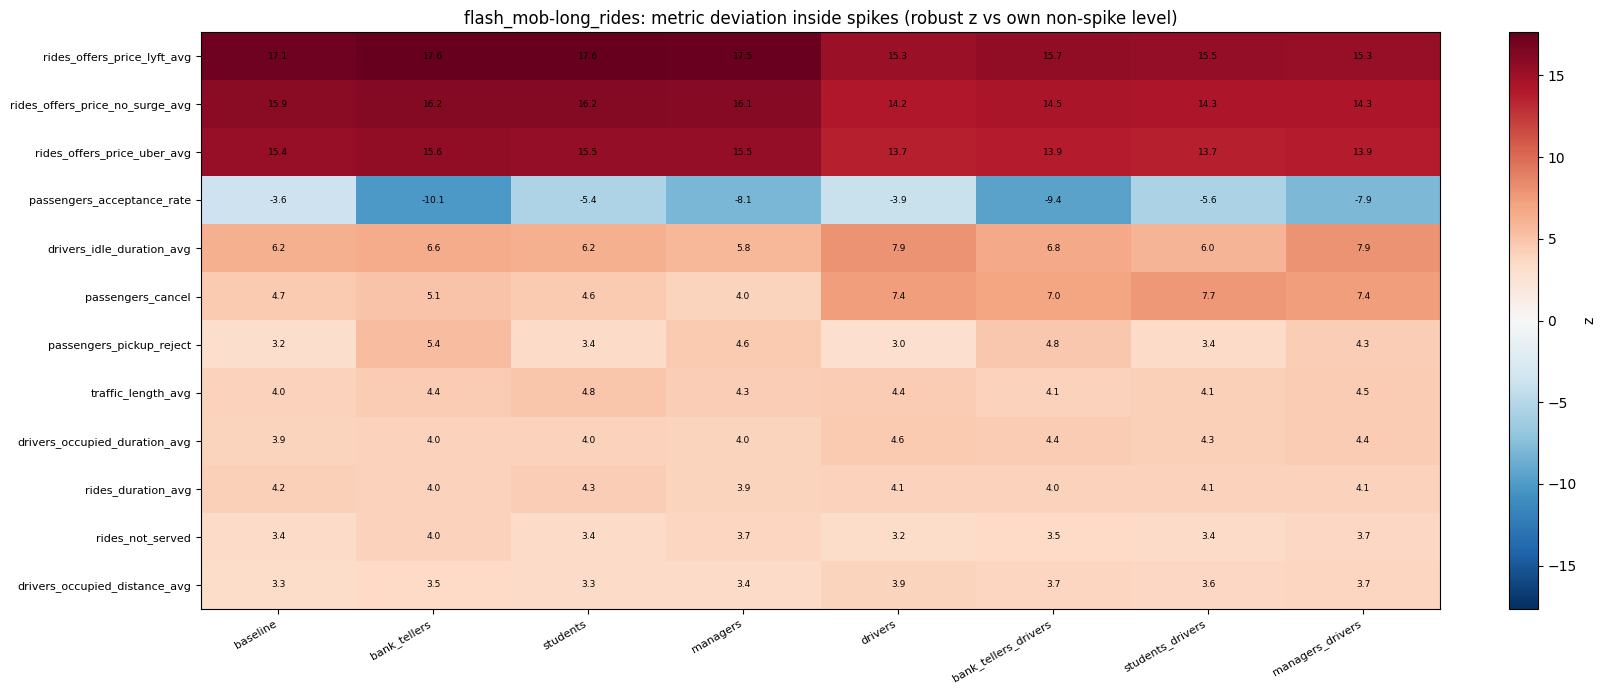

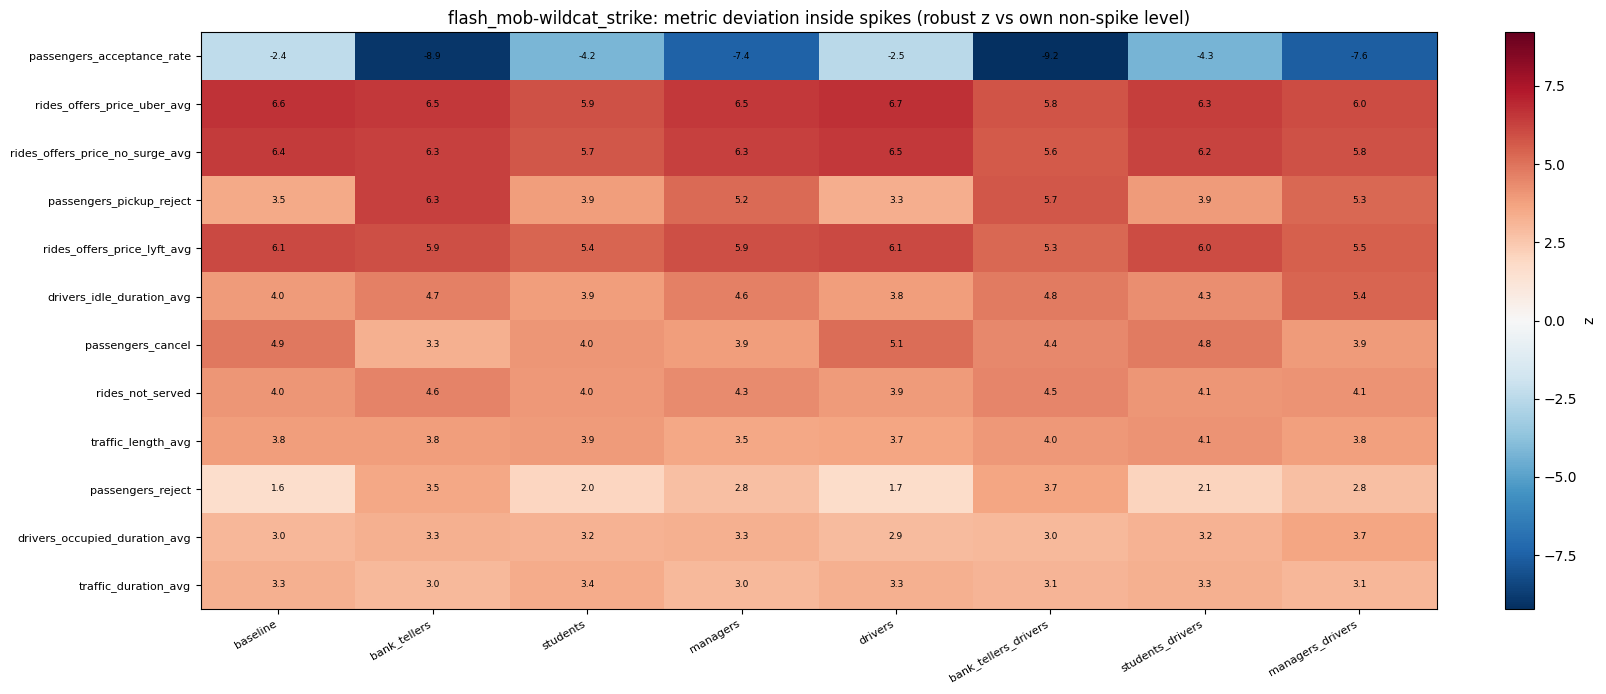

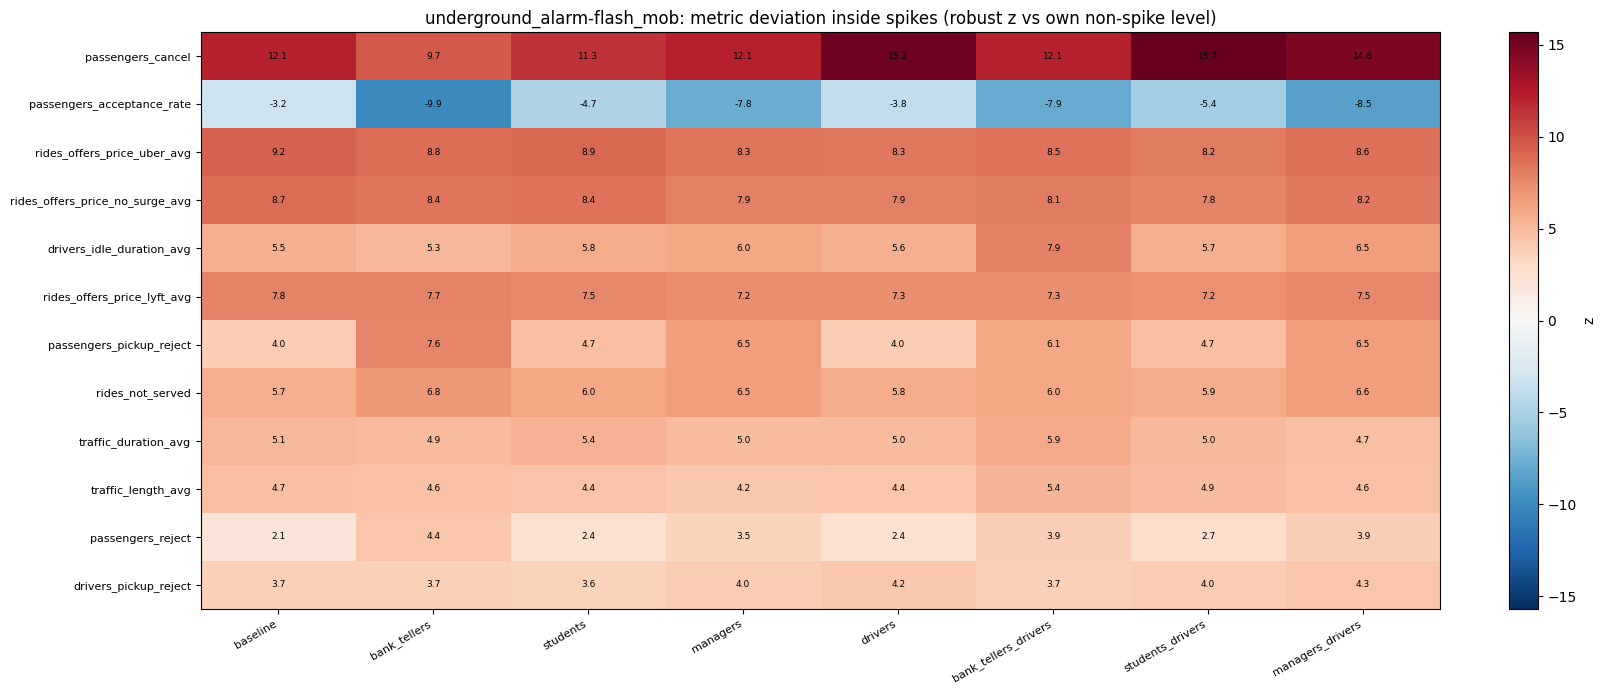

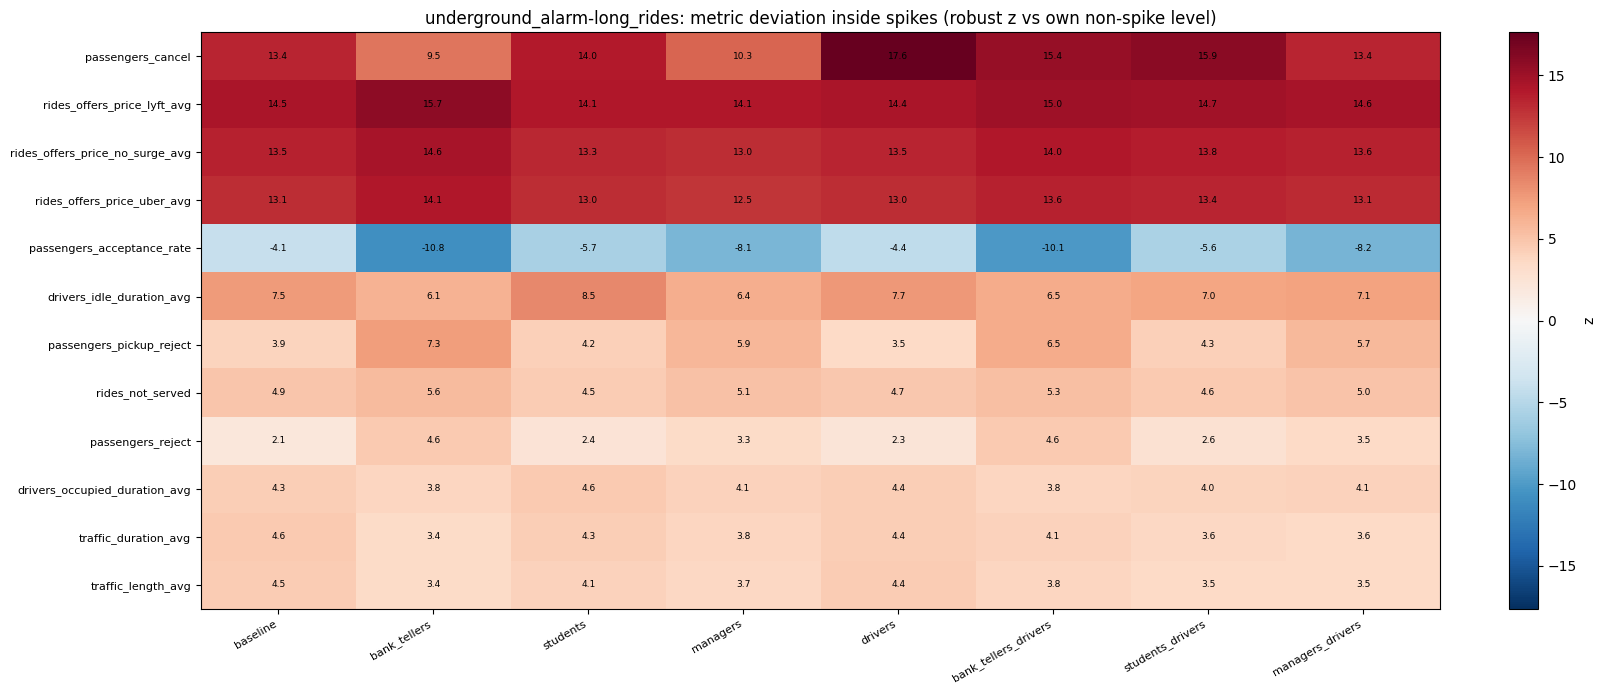

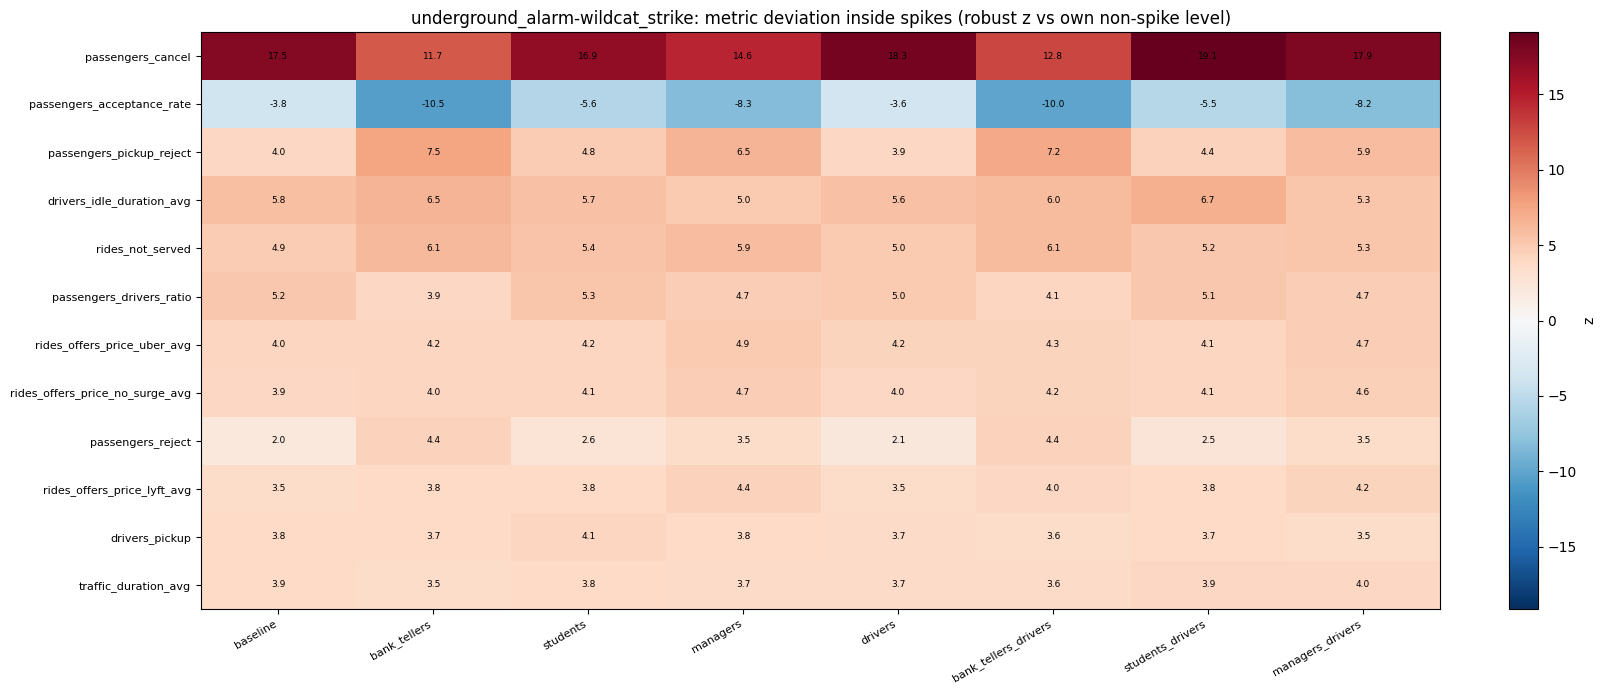

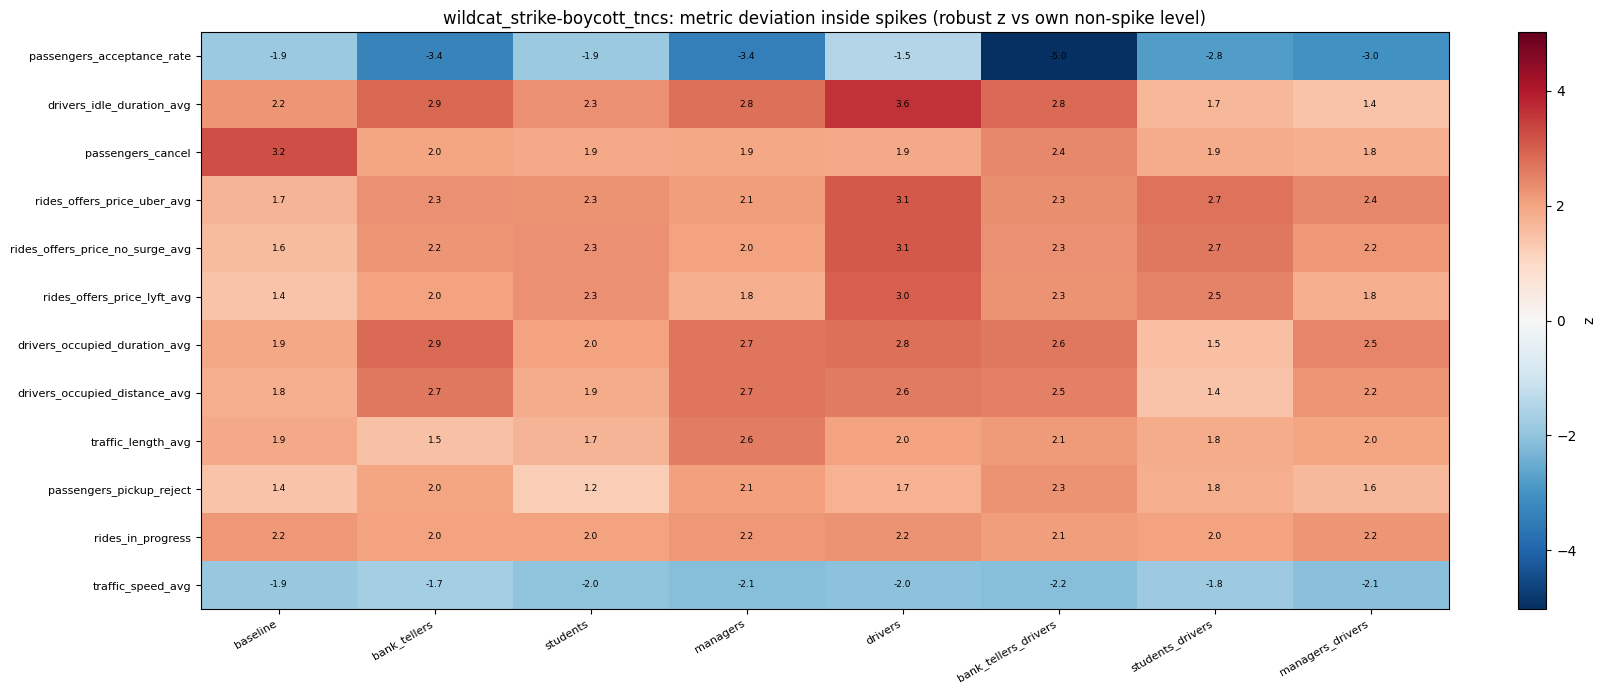

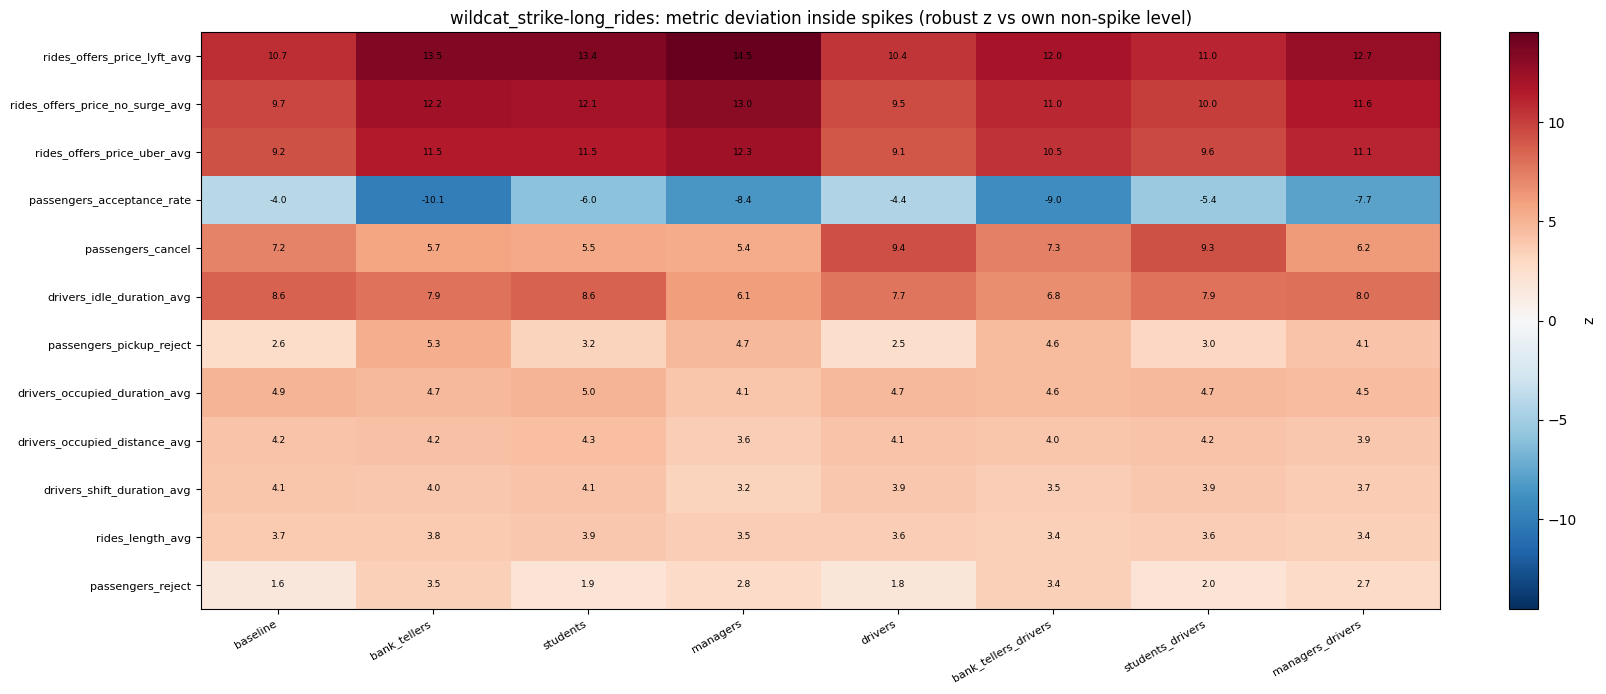

In [24]:
def plot_spike_profile(scen: str, top_k: int = 12, save: bool = True):
    if spike_profile.empty:
        return
    sub = spike_profile[(spike_profile.scenario == scen) & (spike_profile.metric != "failed_requests")]
    if sub.empty:
        return
    order = (sub.assign(a=sub.dev_vs_own.abs()).groupby("metric")["a"].max().sort_values(ascending=False).head(top_k).index.tolist())
    piv = (sub[sub.metric.isin(order)].pivot(index="metric", columns="personality", values="dev_vs_own")
           .reindex(index=order, columns=[p for p in PERSONALITIES if p in set(sub.personality)]))
    if piv.empty:
        return
    lim = float(np.nanmax(np.abs(piv.to_numpy())))
    lim = lim if np.isfinite(lim) and lim > 0 else 1.0
    fig, ax = plt.subplots(figsize=(1.4 * piv.shape[1] + 5, 0.42 * piv.shape[0] + 2))
    im = ax.imshow(piv.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(piv.shape[1]), piv.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(piv.shape[0]), piv.index, fontsize=8)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.iat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6.5)
    ax.set_title(f"{scen}: metric deviation inside spikes (robust z vs own non-spike level)")
    fig.colorbar(im, ax=ax, fraction=0.046, label="z")
    plt.tight_layout()
    if save:
        plt.savefig(OUT_DIR / f"spike_profile_{scen}.png", dpi=300, bbox_inches="tight")
    plt.show()

for scen in SCENARIOS:
    plot_spike_profile(scen)

### Verdicts assembled per run

The spikes of section 3, the rise decomposition of section 4 and the metric profile above, collected per run and joined to the verdicts.

In [25]:
THRESHOLD_LABEL = "normal_ocean_general_general"

if not healthiness_verdicts:
    raise RuntimeError("no verdicts: rq1-healthiness has not been run for these cells")
verdicts = healthiness_verdicts
verdict_source = "rq1-healthiness"
if not failure_detail.empty and not failure_detail["rebuilt_matches"].all():
    off = failure_detail.loc[~failure_detail.rebuilt_matches, ["scenario", "personality"]]
    print(f"  NOTE: the failure timestamp could not be rebuilt for {len(off)} run(s)")

# The verdict of every run, with the spike totals and the rise split already aggregated per cell
CELL_COLS = ["n_spikes", "spike_minutes", "spike_minutes_in_event",
             "d_not_served", "d_cancel", "d_demand", "share_not_served"]
verdict_cells = pd.DataFrame([{"scenario": scen, "personality": pers} for (pers, scen) in runs])
verdict_cells = verdict_cells.merge(
    cell_decomposition.reindex(columns=["scenario", "personality"] + CELL_COLS),
    on=["scenario", "personality"], how="left")
verdict_cells["n_spikes"] = verdict_cells["n_spikes"].fillna(0).astype(int)
for col in ("spike_minutes", "spike_minutes_in_event"):
    verdict_cells[col] = verdict_cells[col].fillna(0.0)
verdict_cells.insert(2, "failure", [bool(verdicts.get((p, s), {}).get("failure", False))
                                    for s, p in zip(verdict_cells.scenario, verdict_cells.personality)])
verdict_cells.insert(3, "failure_timestamp", [verdicts.get((p, s), {}).get("failure_timestamp")
                                              for s, p in zip(verdict_cells.scenario, verdict_cells.personality)])
verdict_cells.to_csv(OUT_DIR / "verdict_cells.csv", index=False)

# The spike each failure sits inside
DEC_COLS = ["d_not_served", "d_cancel", "fr_rise", "share_not_served",
            "not_served_pre", "not_served_spike", "cancel_pre", "cancel_spike"]
GEO_COLS = ["scenario", "personality", "spike_id", "start_ts", "end_ts",
            "duration_min", "peak", "mean", "position"]
EVID_COLS = ["hardiness_peak", "consistency_peak", "resilience_ticks"]
failing_spike_detail = pd.DataFrame(columns=[c for c in GEO_COLS if c != "spike_id"] + DEC_COLS + EVID_COLS)
if not spikes.empty and spikes.contains_failure.any():
    failing_spike_detail = (
        spikes.loc[spikes.contains_failure, GEO_COLS]
        .merge(spike_causes.reindex(columns=["spike_id"] + DEC_COLS), on="spike_id", how="left")
        .merge(failure_detail.reindex(columns=["scenario", "personality"] + EVID_COLS),
               on=["scenario", "personality"], how="left")
        .drop(columns=["spike_id"]))
    failing_spike_detail.to_csv(OUT_DIR / "failing_spike_detail.csv", index=False)
PROFILE_COLS = ["scenario", "personality", "metric", "family", "spike_level",
                "own_baseline_level", "reference_level", "dev_vs_own", "dev_vs_reference"]
failing_metric_profile = pd.DataFrame(columns=PROFILE_COLS)
if not spike_profile.empty:
    failing_metric_profile = (spike_profile[~spike_profile.metric.isin(NOT_A_CAUSE)].reindex(columns=PROFILE_COLS))
    failing_metric_profile.to_csv(OUT_DIR / "failing_metric_profile.csv", index=False)

threshold_summary = pd.DataFrame([{
    "label": THRESHOLD_LABEL, "verdicts": verdict_source,
    "p99_h": thresholds["p99_h"], "p99_c": thresholds["p99_c"], "p99_r": thresholds["p99_r"],
    "failures": int(verdict_cells["failure"].sum()), "runs": len(verdict_cells),
    "spikes": len(spikes)}])
threshold_summary.to_csv(OUT_DIR / "threshold_summary.csv", index=False)

## 9. Emergent characteristics

Metrics whose interaction term is large, meaning the pairing of event and personality produces a deviation that neither the personality nor the event predicts alone.

In [26]:
def signature(dev_col: str, group_key: str, over_key: str,
              z_large: float = Z_LARGE, consistency_min: float = CONSISTENCY_MIN) -> pd.DataFrame:
    sub = cause_rows(attribution).copy()
    sub["dev_z"] = sub[f"{dev_col}_z"]
    sub = sub[np.isfinite(sub.dev_z)]
    if sub.empty:
        return pd.DataFrame()
    rows = []
    for (grp, metric), g in sub.groupby([group_key, "metric"]):
        signs = np.sign(g.dev_z.to_numpy())
        signs = signs[signs != 0]
        if len(signs) == 0:
            continue
        dominant = 1.0 if (signs > 0).sum() >= (signs < 0).sum() else -1.0
        rows.append({group_key: grp, "metric": metric, "family": family_of(metric),
                     "mean_z": float(g.dev_z.mean()),
                     "abs_mean_z": float(abs(g.dev_z.mean())),
                     "direction": "up" if dominant > 0 else "down",
                     "sign_consistency": float((signs == dominant).mean()),
                     "n": int(g[over_key].nunique())})
    out = pd.DataFrame(rows)
    out["is_trait"] = (out.abs_mean_z >= z_large) & (out.sign_consistency >= consistency_min)
    return out.sort_values([group_key, "abs_mean_z"], ascending=[True, False])

personality_signature = signature("pers_dev", "personality", "scenario")
personality_signature = personality_signature[personality_signature.personality != BASELINE]
personality_signature.to_csv(OUT_DIR / "signature_personality.csv", index=False)
scenario_signature = signature("scen_dev", "scenario", "personality")
scenario_signature = scenario_signature[scenario_signature.scenario != REFERENCE_SCENARIO]
scenario_signature.to_csv(OUT_DIR / "signature_scenario.csv", index=False)

for name, tbl, key in [("personality", personality_signature, "personality"), ("event", scenario_signature, "scenario")]:
    print(f"\n{name} traits (|mean z| >= {Z_LARGE}, sign consistency >= {CONSISTENCY_MIN}):")
    traits = tbl[tbl.is_trait]
    if traits.empty:
        print("None passed the threshold; showing the strongest candidates instead")
        traits = tbl.groupby(key).head(TOP_K)
    display(traits.groupby(key).head(8)[
        [key, "metric", "family", "mean_z", "direction", "sign_consistency"]].round(2).rename(columns={"scenario": "event"}))


personality traits (|mean z| >= 1.0, sign consistency >= 1.0):


,personality,metric,family,mean_z,direction,sign_consistency
20,bank_tellers,passengers_acceptance_rate,passenger_decisions,-5.81,down,1.0
28,bank_tellers,passengers_pickup_reject,passenger_decisions,1.82,up,1.0
31,bank_tellers,passengers_reject,passenger_decisions,1.41,up,1.0
69,bank_tellers_drivers,passengers_acceptance_rate,passenger_decisions,-5.97,down,1.0
77,bank_tellers_drivers,passengers_pickup_reject,passenger_decisions,1.81,up,1.0
80,bank_tellers_drivers,passengers_reject,passenger_decisions,1.60,up,1.0
167,managers,passengers_acceptance_rate,passenger_decisions,-4.13,down,1.0
175,managers,passengers_pickup_reject,passenger_decisions,1.26,up,1.0
216,managers_drivers,passengers_acceptance_rate,passenger_decisions,-4.22,down,1.0
224,managers_drivers,passengers_pickup_reject,passenger_decisions,1.22,up,1.0



event traits (|mean z| >= 1.0, sign consistency >= 1.0):


,event,metric,family,mean_z,direction,sign_consistency
28,boycott_tncs,passengers_pickup_reject,passenger_decisions,-2.37,down,1.0
42,boycott_tncs,rides_offers_radius_avg,matching,-2.34,down,1.0
31,boycott_tncs,passengers_reject,passenger_decisions,-1.89,down,1.0
12,boycott_tncs,drivers_pickup_reject,driver_decisions,-1.86,down,1.0
22,boycott_tncs,passengers_change_provider,passenger_decisions,-1.75,down,1.0
...,...,...,...,...,...,...
679,wildcat_strike-long_rides,rides_offers_radius_avg,matching,2.25,up,1.0
665,wildcat_strike-long_rides,passengers_pickup_reject,passenger_decisions,1.60,up,1.0
657,wildcat_strike-long_rides,passengers_acceptance_rate,passenger_decisions,-1.42,down,1.0
661,wildcat_strike-long_rides,passengers_drivers_ratio,demand,1.35,up,1.0


In [27]:
emergent = cause_rows(attribution).copy()
emergent["abs_z"] = emergent["interaction_effect_z"].abs()
emergent = emergent[np.isfinite(emergent.abs_z) & (emergent.scenario != REFERENCE_SCENARIO) & (emergent.personality != BASELINE)]
emergent = (emergent.sort_values("abs_z", ascending=False).groupby(["scenario", "personality"], sort=False).head(TOP_K))
emergent.to_csv(OUT_DIR / "emergent_interaction.csv", index=False)
print("Emergent: metrics that only move when this personality meets this event:")
display(emergent[["scenario", "personality", "metric", "family", "interaction_effect",
                  "interaction_effect_z"]].round(3).head(30).rename(columns={"scenario": "event"}))

Emergent: metrics that only move when this personality meets this event:


,event,personality,metric,family,interaction_effect,interaction_effect_z
2415,wildcat_strike,managers,drivers_idle_duration_avg,supply,323.265,2.724
2863,boycott_tncs-long_rides,managers,drivers_idle_duration_avg,supply,299.173,2.521
5999,wildcat_strike-boycott_tncs,managers,drivers_idle_duration_avg,supply,296.560,2.499
4655,underground_alarm-flash_mob,managers,drivers_idle_duration_avg,supply,276.145,2.327
5439,underground_alarm-wildcat_strike,bank_tellers,drivers_idle_duration_avg,supply,261.309,2.202
5719,underground_alarm-wildcat_strike,students_drivers,drivers_idle_duration_avg,supply,248.971,2.098
3199,flash_mob-boycott_tncs,bank_tellers,drivers_idle_duration_avg,supply,241.249,2.033
5495,underground_alarm-wildcat_strike,students,drivers_idle_duration_avg,supply,234.956,1.980
1519,long_rides,managers,drivers_idle_duration_avg,supply,231.483,1.951
1110,flash_mob,managers,rides_offers_price_uber_avg,market,-1.216,-1.945


## 10. Under what conditions does a personality fail?

For every metric, the event-window level is compared between the failing and the passing runs of the personality:

- `separation`: the probability that a failing run shows a higher (or lower) level than a passing one. 1.0 means the two groups do not overlap at all.
- `gap_z`: the difference between the two medians, in the robust z units.

In [28]:
# Failure conditions per personality
COND_TOP = 5            # Conditions reported per personality
COND_MIN_SEP = 0.7      # Below this a condition is not worth listing
COND_SPECIFIC = 0.15    # Separation margin over the other personalities that makes a condition specific
TOL_MIN_PERS = 5        # A "shared" condition has to separate failures for this many personalities

verdicts_now = verdicts
cond_levels = cause_rows(attribution)
cond_levels = cond_levels[cond_levels.scenario != REFERENCE_SCENARIO]

def rank_separation(x_fail: np.ndarray, x_pass: np.ndarray) -> float:
    gt = (x_fail[:, None] > x_pass[None, :]).mean()
    eq = (x_fail[:, None] == x_pass[None, :]).mean()
    return float(gt + 0.5 * eq)

def best_cut(x: np.ndarray, fail: np.ndarray, direction: str) -> tuple[float, float]:
    order = np.argsort(x)
    xs, fs = x[order], fail[order]
    best = (np.nan, 0.0)
    for i in range(1, len(xs)):
        if xs[i] == xs[i - 1]:
            continue
        cut = 0.5 * (xs[i] + xs[i - 1])
        pred = (x > cut) if direction == "high" else (x < cut)
        acc = float((pred == fail).mean())
        if acc > best[1]:
            best = (float(cut), acc)
    return best

cond_rows = []
for pers in PERSONALITIES:
    sub = cond_levels[cond_levels.personality == pers]
    scen_list = sorted(sub.scenario.unique())
    fail_of = {s: bool(verdicts_now.get((pers, s), {}).get("failure", False)) for s in scen_list}
    n_fail = sum(fail_of.values()); n_pass = len(scen_list) - n_fail
    if n_fail < 2 or n_pass < 2:
        continue
    for m, g in sub.groupby("metric"):
        g = g.dropna(subset=["level"])
        if g.scenario.nunique() < len(scen_list):
            continue
        lv = g.set_index("scenario").level.reindex(scen_list).to_numpy(dtype=float)
        fl = np.array([fail_of[s] for s in scen_list])
        auc = rank_separation(lv[fl], lv[~fl])
        direction = "high" if auc >= 0.5 else "low"
        sep = max(auc, 1.0 - auc)
        scale = float(g.scale.iloc[0]) if np.isfinite(g.scale.iloc[0]) and g.scale.iloc[0] > 0 else np.nan
        med_f, med_p = float(np.median(lv[fl])), float(np.median(lv[~fl]))
        cut, acc = best_cut(lv, fl, direction)
        cond_rows.append({"personality": pers, "metric": m, "family": family_of(m),
                          "n_fail": n_fail, "n_pass": n_pass, "separation": sep, "direction": direction,
                          "median_fail": med_f, "median_pass": med_p,
                          "gap_z": (med_f - med_p) / scale if np.isfinite(scale) else np.nan,
                          "cut": cut, "accuracy": acc})
conditions_all = pd.DataFrame(cond_rows)

if conditions_all.empty:
    failure_conditions = pd.DataFrame()
    tolerance = pd.DataFrame()
    print("No personality has both failing and passing runs: no conditions to report.")
else:
    others = []
    for (pers, m), r in conditions_all.set_index(["personality", "metric"]).iterrows():
        o = conditions_all[(conditions_all.metric == m) & (conditions_all.personality != pers)]
        others.append(float(o.separation.mean()) if len(o) else np.nan)
    conditions_all["others_separation"] = others
    conditions_all["specificity"] = conditions_all.separation - conditions_all.others_separation
    conditions_all["specific"] = ((conditions_all.separation >= 0.85) & (conditions_all.specificity >= COND_SPECIFIC))
    strong = (conditions_all[conditions_all.separation >= COND_MIN_SEP]
              .sort_values(["personality", "separation", "accuracy"], ascending=[True, False, False])
              .groupby("personality").head(COND_TOP))
    specific = (conditions_all[(conditions_all.separation >= COND_MIN_SEP) & (conditions_all.specificity >= COND_SPECIFIC)]
                .sort_values(["personality", "specificity"], ascending=[True, False])
                .groupby("personality").head(3))
    failure_conditions = (pd.concat([strong, specific]).drop_duplicates(["personality", "metric"])
                          .sort_values(["personality", "separation", "specificity"], ascending=[True, False, False])
                          .reset_index(drop=True))
    skipped = [p for p in PERSONALITIES if p not in conditions_all.personality.unique()]
    if skipped:
        print(f"No conditions for {skipped}: fewer than two failing or two passing runs")
    failure_conditions.to_csv(OUT_DIR / "failure_conditions.csv", index=False)

    shared = (conditions_all[conditions_all.separation >= COND_MIN_SEP]
              .groupby("metric").personality.nunique())
    shared = shared[shared >= TOL_MIN_PERS].index
    tolerance = conditions_all[conditions_all.metric.isin(shared)].copy()
    tolerance["mean_separation"] = tolerance.groupby("metric").separation.transform("mean")
    tolerance = tolerance.sort_values(["mean_separation", "metric", "personality"], ascending=[False, True, True])
    tolerance.to_csv(OUT_DIR / "failure_tolerance.csv", index=False)

    print(f"failure_conditions.csv: {len(failure_conditions)} conditions over "
          f"{failure_conditions.personality.nunique()} personalities; "
          f"{int(failure_conditions.specific.sum())} personality-specific")
    print("Top conditions per personality:")
    display(failure_conditions[["personality", "metric", "family", "direction", "separation",
                                "gap_z", "cut", "accuracy", "others_separation", "specificity", "specific"]].round(3))
    if len(shared):
        print(f"{len(shared)} conditions shared by >= {TOL_MIN_PERS} personalities:")
        display(tolerance.pivot_table(index="metric", columns="personality", values="cut")
                .reindex(columns=[p for p in PERSONALITIES if p in tolerance.personality.unique()]).round(2))


failure_conditions.csv: 46 conditions over 8 personalities; 11 personality-specific
Top conditions per personality:


,personality,metric,family,direction,separation,gap_z,cut,accuracy,others_separation,specificity,specific
0,bank_tellers,drivers_passengers_served,supply,high,0.878,0.423,2.306,0.929,0.719,0.159,True
1,bank_tellers,passengers_pickup_reject,passenger_decisions,high,0.878,2.053,0.306,0.929,0.761,0.117,False
2,bank_tellers,drivers_idle,supply,low,0.857,-0.279,7108.829,0.857,0.655,0.202,True
3,bank_tellers,drivers_pickup_reject,driver_decisions,high,0.857,1.469,0.302,0.929,0.789,0.068,False
4,bank_tellers,drivers_removed,supply,high,0.857,0.632,0.474,0.929,0.804,0.053,False
5,bank_tellers_drivers,rides_offers_price_lyft_avg,market,high,0.792,3.984,21.899,0.857,0.630,0.161,False
6,bank_tellers_drivers,drivers_change_zone,driver_decisions,high,0.792,0.649,0.941,0.786,0.736,0.056,False
7,bank_tellers_drivers,drivers_change_provider,driver_decisions,high,0.792,0.805,0.467,0.786,0.774,0.018,False
8,bank_tellers_drivers,drivers_reject,driver_decisions,high,0.792,0.870,0.718,0.786,0.782,0.009,False
9,bank_tellers_drivers,passengers_change_provider,passenger_decisions,high,0.792,1.267,1.857,0.786,0.789,0.002,False


21 conditions shared by >= 5 personalities:


personality,baseline,bank_tellers,students,managers,drivers,bank_tellers_drivers,students_drivers,managers_drivers
metric,,,,,,,,
drivers_acceptance_rate,1.93,1.93,1.85,1.89,1.65,2.10,1.83,1.98
drivers_change_provider,0.90,0.85,0.93,0.94,0.95,0.47,0.94,0.92
drivers_change_zone,1.55,1.54,1.56,1.55,1.55,0.94,1.13,1.55
drivers_pickup,1251.70,1009.89,1234.87,1152.19,1238.77,385.82,1222.38,414.37
drivers_pickup_accept,1.34,1.18,1.43,1.32,1.39,0.40,1.38,0.42
drivers_pickup_reject,0.33,0.30,0.34,0.32,0.35,0.10,0.35,0.33
drivers_reject,1.41,1.32,1.44,1.47,1.43,0.72,1.49,1.41
drivers_removed,0.51,0.47,0.53,0.49,0.55,0.24,0.51,0.51
drivers_waiting,3.21,3.24,3.18,3.24,3.17,1.71,3.19,1.74


## 11. Dashboard export & summary

In [29]:
def top_string(tbl: pd.DataFrame, value_col: str, k: int = 3) -> pd.Series:
    if tbl.empty:
        return pd.Series(dtype=object)
    t = tbl.copy()
    t["_abs"] = t[value_col].abs()
    t = t.sort_values("_abs", ascending=False).groupby(["scenario", "personality"]).head(k)
    return (t.assign(_s=lambda d: d.metric + " (" + d[value_col].map(lambda v: f"{v:+.2f}") + ")")
            .groupby(["scenario", "personality"])["_s"].apply("; ".join))

FR_EFFECT_RENAME = {"scenario_effect": "fr_scenario_effect",
                    "personality_effect": "fr_personality_effect",
                    "interaction_effect": "fr_interaction_effect",
                    "total_effect": "fr_total_effect"}
dashboard = fr_overview.set_index(["scenario", "personality"])
if fr_attrib.empty:
    for col in FR_EFFECT_RENAME.values():
        dashboard[col] = np.nan
else:
    dashboard = dashboard.join(
        fr_attrib.set_index(["scenario", "personality"])[list(FR_EFFECT_RENAME)]
        .rename(columns=FR_EFFECT_RENAME), how="left")

if not cell_decomposition.empty:
    dashboard = dashboard.join(
        cell_decomposition.set_index(["scenario", "personality"])[
            ["n_spikes", "spike_minutes", "spike_minutes_in_event", "d_not_served", "d_cancel",
             "d_demand", "share_not_served", "share_cancel", "dominant_driver",
             "failure_mode"]], how="left")
else:
    for col in ["n_spikes", "spike_minutes", "spike_minutes_in_event", "d_not_served",
                "d_cancel", "d_demand", "share_not_served", "share_cancel"]:
        dashboard[col] = np.nan
    dashboard["dominant_driver"] = np.nan
    dashboard["failure_mode"] = np.nan

dashboard["n_spikes"] = dashboard["n_spikes"].fillna(0).astype(int)
for col in ["spike_minutes", "spike_minutes_in_event"]:
    dashboard[col] = dashboard[col].fillna(0.0)
dashboard["dominant_driver"] = dashboard["dominant_driver"].fillna("none")
dashboard["failure_mode"] = dashboard["failure_mode"].fillna("no spike")
dashboard["causes_scenario"] = top_string(cause_tables["scenario"], "scenario_effect_z")
dashboard["causes_personality"] = top_string(cause_tables["personality"], "personality_effect_z")
dashboard["causes_interaction"] = top_string(cause_tables["interaction"], "interaction_effect_z")
dashboard["causes_in_spike"] = (top_string(spike_causes_ranked, "dev_vs_own") if not spike_causes_ranked.empty else np.nan)

def trait_string(tbl: pd.DataFrame, key: str, k: int = 3) -> pd.Series:
    traits = tbl[tbl.is_trait] if "is_trait" in tbl.columns else tbl
    if traits.empty:
        return pd.Series(dtype=object)
    traits = traits.sort_values("abs_mean_z", ascending=False).groupby(key).head(k)
    return (traits.assign(_s=lambda d: d.metric + " " + d.direction.map({"up": "^", "down": "v"}))
            .groupby(key)["_s"].apply("; ".join))

pers_trait_str = trait_string(personality_signature, "personality")
scen_trait_str = trait_string(scenario_signature, "scenario")
emergent_str = top_string(emergent, "interaction_effect_z").to_dict()

dashboard = dashboard.reset_index()
dashboard["personality_traits"] = dashboard["personality"].map(pers_trait_str)
dashboard["scenario_traits"] = dashboard["scenario"].map(scen_trait_str)
dashboard["emergent_traits"] = [emergent_str.get((s, p)) for s, p in zip(dashboard["scenario"], dashboard["personality"])]

if not scenario_additivity.empty:
    add = (scenario_additivity[scenario_additivity.metric == "failed_requests"]
           .set_index(["scenario", "personality"]))
    idx = pd.MultiIndex.from_arrays([dashboard["scenario"], dashboard["personality"]])
    dashboard["fr_expected_from_components"] = add["expected"].reindex(idx).to_numpy()
    dashboard["fr_component_residual"] = add["residual"].reindex(idx).to_numpy()
else:
    dashboard["fr_expected_from_components"] = np.nan
    dashboard["fr_component_residual"] = np.nan

verdict_rows = pd.DataFrame([
    {"scenario": scen, "personality": pers, **v}
    for (pers, scen), v in healthiness_verdicts.items()])
if failure_table is not None and "personality" in failure_table.columns:
    keep = [c for c in ["scenario", "personality", "failure", "failure_timestamp"]
            if c in failure_table.columns]
    dashboard = dashboard.merge(failure_table[keep].drop_duplicates(["scenario", "personality"]),
                                on=["scenario", "personality"], how="left")
else:
    dashboard = dashboard.merge(verdict_rows, on=["scenario", "personality"], how="left")
    print("failure verdicts taken from the cached rq1-healthiness pickles")

DASHBOARD_COLUMNS = [
    "scenario", "personality", "is_compound", "mechanism",
    "failure", "failure_timestamp",
    "fr_mean", "fr_mean_event", "fr_p99", "fr_peak", "minutes_above_threshold",
    "n_spikes", "spike_minutes", "spike_minutes_in_event",
    "failure_mode", "dominant_driver", "share_not_served", "share_cancel",
    "d_not_served", "d_cancel", "d_demand",
    "fr_scenario_effect", "fr_personality_effect", "fr_interaction_effect", "fr_total_effect",
    "fr_expected_from_components", "fr_component_residual",
    "causes_scenario", "causes_personality", "causes_interaction", "causes_in_spike",
    "scenario_traits", "personality_traits", "emergent_traits", "index_source"
]
dashboard = dashboard.reindex(columns=DASHBOARD_COLUMNS)
dashboard = dashboard.sort_values(
    ["scenario", "personality"],
    key=lambda col: col.map({**{s: i for i, s in enumerate(SCENARIOS)}, **{p: i for i, p in enumerate(PERSONALITIES)}})
).reset_index(drop=True)
dashboard.to_csv(OUT_DIR / "dashboard.csv", index=False)
print(f"Wrote {OUT_DIR / 'dashboard.csv'}: {len(dashboard)} rows x {len(dashboard.columns)} columns")

Wrote analysis_out/rq3-analysis/dashboard.csv: 120 rows x 35 columns


In [30]:
manifest = {
    "generated_from": "rq3-analysis.ipynb",
    "data_root": str(DATA_ROOT),
    "index": "failed_requests = w(passengers_new) * (rides_not_served + passengers_cancel) / passengers_new",
    "index_produced_by": "rq1-healthiness.ipynb",
    "index_sources": pd.Series(index_source).value_counts().to_dict(),
    "threshold_baseline": THRESHOLD_BASELINE,
    "thresholds": {k: float(v) for k, v in thresholds.items()},
    "spike_threshold": FR_THRESHOLD,
    "index_components": FR_COMPONENTS,
    "simulation_end": SIM_END,
    "plot_window": list(PLOT_WINDOW),
    "reference_config": list(REF_KEY),
    "preprocessing": {"window_fill": WINDOW_FILL, "aggregate": AGGREGATE, "cut": CUT,
                      "stride": STRIDE, "analysis_start": ANALYSIS_START},
    "scenarios": SCENARIOS,
    "compound_scenarios": COMPOUND_SCENARIOS,
    "personalities": PERSONALITIES,
    "event_windows": {s: list(event_window(s)) for s in SCENARIOS},
    "files": sorted(p.name for p in OUT_DIR.glob("*.csv"))
}
(OUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"Wrote {OUT_DIR / 'manifest.json'}: {len(manifest['files'])} csv files listed")

Wrote analysis_out/rq3-analysis/manifest.json: 27 csv files listed


In [31]:
FAILING = {(s, p) for s, p, f in zip(dashboard.scenario, dashboard.personality, dashboard.failure)
           if f is True or f == True}

def is_failing(frame: pd.DataFrame) -> np.ndarray:
    return np.array([(s, p) in FAILING for s, p in zip(frame.scenario, frame.personality)], dtype=bool)

fr = fr_attrib.merge(dashboard[["scenario", "personality", "failure"]], on=["scenario", "personality"])
fr["failure"] = fr["failure"].astype(bool)
summary = {}

acc = personality_signature[personality_signature.metric == "passengers_acceptance_rate"].set_index("personality")
summary["acceptance_rate_signature_z"] = {POPULATION_LABEL[p]: round(float(acc.at[p, "mean_z"]), 2)
                                              for p in POPULATIONS if p in acc.index}
drv = attribution[(attribution.personality == DRIVER_ONLY) & (attribution.metric == "drivers_acceptance_rate")]
drv = drv[is_failing(drv)]
summary["drivers_acceptance_rate_in_failing_runs_z"] = {
    "pers_dev_z": round(float(drv.pers_dev_z.mean()), 2),
    "personality_effect_z": round(float(drv.personality_effect_z.mean()), 2)}
fa = personality_additivity[personality_additivity.metric == "failed_requests"]
summary["combined_additivity_within_0.03"] = [int((fa.residual.abs() <= 0.03).sum()), int(len(fa))]
summary["combined_additivity_exceptions"] = [
    {"scenario": scenario_label(r.scenario), "population": POPULATION_LABEL[r.personality],
     "residual": round(float(r.residual), 3)} for r in fa[fa.residual.abs() > 0.03].itertuples()]

pers_cells = fr[fr.personality != BASELINE]
summary["personality_term_positive"] = [int((pers_cells.personality_effect > 0).sum()), int(len(pers_cells))]
summary["personality_term_never_negative"] = [
    POPULATION_LABEL[p] for p, g in pers_cells.groupby("personality") if (g.personality_effect >= 0).all()]
summary["personality_term_mean"] = {POPULATION_LABEL[p]: round(float(g.personality_effect.mean()), 4)
                                        for p, g in pers_cells.groupby("personality")}
summary["personality_term_largest_in"] = {
    POPULATION_LABEL[p]: scenario_label(g.loc[g.personality_effect.idxmax(), "scenario"])
    for p, g in pers_cells.groupby("personality")}

terms = ["scenario_effect", "personality_effect", "interaction_effect"]
failing_pers = pers_cells[pers_cells.failure]
shares = failing_pers[terms].abs().sum() / failing_pers[terms].abs().sum().sum()
summary["share_of_absolute_effects_in_failing_runs"] = {t.split("_")[0]: round(float(v), 3) for t, v in shares.items()}

general_fails = {s for s in SCENARIOS if (s, BASELINE) in FAILING}
hidden = failing_pers[~failing_pers.scenario.isin(general_fails)]
summary["failing_only_with_personality"] = {
    "runs": int(len(hidden)),
    "mean_terms": {t.split("_")[0]: round(float(hidden[t].mean()), 4) for t in terms},
    "personality_plus_interaction_exceeds_scenario": int(
        ((hidden.personality_effect + hidden.interaction_effect) > hidden.scenario_effect).sum()),
    "scenario_term_negative": int((hidden.scenario_effect < 0).sum())}

fail_spikes = spike_causes[spike_causes.contains_failure]
by_pop = fail_spikes.groupby("personality")
summary["failing_spike_share_not_served"] = {POPULATION_LABEL[p]: round(float(v), 3)
                                                 for p, v in by_pop.share_not_served.mean().items()}
summary["failing_spike_not_served_over_cancel_rise"] = {
    POPULATION_LABEL[p]: round(float(g.d_not_served.mean() / g.d_cancel.mean()), 2) for p, g in by_pop}

fam = family_effects[family_effects.personality != BASELINE]
pers_fam = fam.groupby(["personality", "family"]).personality_effect.mean().unstack()
inter_fam = (fam[fam.scenario != REFERENCE_SCENARIO].groupby(["personality", "family"]).interaction_effect.mean().unstack())
summary["personality_term_family_z"] = {POPULATION_LABEL[p]: pers_fam.loc[p].round(2).to_dict() for p in POPULATIONS[1:]}
summary["interaction_term_market_z"] = {POPULATION_LABEL[p]: round(float(inter_fam.at[p, "market"]), 2) for p in POPULATIONS[1:]}

LEAD_METRICS = ["rides_offers_price_no_surge_avg", "rides_offers_price_uber_avg",
                "rides_offers_price_lyft_avg", "passengers_acceptance_rate", "drivers_idle_duration_avg"]
lead = spike_profile[spike_profile.metric.isin(LEAD_METRICS) & is_failing(spike_profile)]
lead = lead.groupby(["personality", "metric"]).lead_dev.mean().unstack().reindex(POPULATIONS)
summary["lead_before_failing_spikes_z_range"] = {
    m: [round(float(lead[m].min()), 1), round(float(lead[m].max()), 1)] for m in LEAD_METRICS}

for k in ("personality_term_positive", "share_of_absolute_effects_in_failing_runs", "combined_additivity_within_0.03", "failing_only_with_personality"):
    print(f"{k}: {summary[k]}")


personality_term_positive: [95, 105]
share_of_absolute_effects_in_failing_runs: {'scenario': 0.702, 'personality': 0.165, 'interaction': 0.133}
combined_additivity_within_0.03: [43, 45]
failing_only_with_personality: {'runs': 29, 'mean_terms': {'scenario': 0.0244, 'personality': 0.0181, 'interaction': 0.0064}, 'personality_plus_interaction_exceeds_scenario': 14, 'scenario_term_negative': 9}


In [32]:
(OUT_DIR / "rq3_summary.json").write_text(json.dumps(summary, indent=2))
print(f"Wrote {OUT_DIR / 'rq3_summary.json'}")

Wrote analysis_out/rq3-analysis/rq3_summary.json
